<strong><span style='font-size:40px;color:red'>Transformer build first go (ZPT)

In [93]:
print("starting imports...")
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib import pyplot as plt
import re
from collections import Counter, defaultdict
import nltk
print("Imports completed.")

device = torch.device('mps' if torch.backends.mps.is_built() else 'cpu')
print(f"Using device: {device}")
device = 'cpu'  # Force CPU usage
d_model = 256
train_fresh = True

starting imports...
Imports completed.
Using device: mps


<strong><span style='font-size:25px;color:red'>char tokeniser

In [94]:
class charTokeniser:
    import numpy as np

    def __init__(self, text:str):

        chars = sorted(set(text))
        self.vobab_size = len(chars)

        self.stoi = {ch:i for i, ch in enumerate(chars)}
        self.itos = {i:ch for i, ch in enumerate(chars)}

    def encode(self, text:str):
        return np.array([self.stoi[ch] for ch in text], dtype=np.int64)
    
    def decode(self, tokens:np.ndarray):
        return ''.join([self.itos[int(i)] for i in tokens])

<strong><span style='font-size:25px;color:red'>char embedding

In [95]:
class tokeEmbedding:
    import numpy as np

    def __init__(self, vocab_size, embedding_dim):
        self.weight = np.random.randn(vocab_size, embedding_dim) * 0.01

    def forward(self, toekn_ids):
        return self.weight[toekn_ids]

<strong><span style='font-size:25px;color:red'>sinusoidal positional encoding

In [96]:
def positionalEncoding(seq_len, d_model):
    import numpy as np

    pe =  np.zeros((seq_len, d_model))
    position = np.arange(seq_len)[:,None]
    div_term = np.exp(
        np.arange(0,d_model, 2) * (-np.log(10000.0)/d_model)
    )

    pe[:,0::2] = np.sin(position * div_term)
    pe[:,1::2] = np.cos(position * div_term)

    return pe

<strong><span style='font-size:25px;color:red'>Attention mechanism

In [97]:
import numpy as np

def stable_softmax(x, axis=-1):
    x = x-np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.num_heads = num_heads
        self.head_size = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.fc_out = nn.Linear(d_model, d_model)
        
        self.scale = self.head_size ** 0.5

    def forward(self, x):
        batch_size, seq_len, d_model = x.shape
        
        Q = self.W_q(x).view(batch_size, seq_len, self.num_heads, self.head_size).transpose(1, 2)
        K = self.W_k(x).view(batch_size, seq_len, self.num_heads, self.head_size).transpose(1, 2)
        V = self.W_v(x).view(batch_size, seq_len, self.num_heads, self.head_size).transpose(1, 2)
        
        # Calculate raw scores
        scores = (Q @ K.transpose(-2, -1)) / self.scale
        
        # --- CAUSAL MASK START ---
        # Create a triangular mask (1s above the diagonal, 0s on/below)
        # We move it to the same device as x (MPS/CPU)
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()
        
        # Fill the "future" positions with -infinity so they become 0 after softmax
        scores = scores.masked_fill(mask, float('-inf'))
        # --- CAUSAL MASK END ---
        
        weights = torch.softmax(scores, dim=-1)
        out = weights @ V
        
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
        return self.fc_out(out), weights
    



<strong><span style='font-size:25px;color:red'> Feed forwards mechanisms

In [98]:
class FeedForwards(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        return x

<strong><span style='font-size:25px;color:red'> Layered Normalisation

In [99]:
class layerNorm:
    def __init__ (self, d_model, eps=1e-6):
        self.gamma = np.ones(d_model)
        self.beta = np.zeros(d_model)
        self.eps = eps

    def forward(self, x):
        # x : (seq_len, d_model)

        mean = x.mean(axis=-1, keepdims=True)
        std = x.std(axis=-1, keepdims=True)
        x_norm = (x - mean) / (std + self.eps)

        return self.gamma * x_norm + self.beta

<strong><span style='font-size:25px;color:red'> Transformer Bock

In [100]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, d_ff, num_heads): # Add num_heads here
        super().__init__()

        # Now we pass both arguments as required
        self.attn = MultiHeadAttention(d_model, num_heads) 
        self.ff = FeedForwards(d_model, d_ff)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out, attn_weights = self.attn(x)
        x = self.ln1(x + attn_out)
        ff_out = self.ff(x)
        x = self.ln2(x + ff_out)
        return x, attn_weights



class TransformerEncoder(nn.Module):
    def __init__(self, num_layers, d_model, d_ff, vocab_size, max_seq_len, num_heads=4): # Add num_heads with a default
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        
        pe = torch.tensor(positionalEncoding(max_seq_len, d_model), dtype=torch.float32)
        self.register_buffer("pos_encoding", pe)

        # Pass num_heads into every block we create
        self.layers = nn.ModuleList(
            [TransformerBlock(d_model, d_ff, num_heads) for _ in range(num_layers)]
        )

        self.output = nn.Linear(d_model, vocab_size)
        self.d_model = d_model

    def forward(self, token_ids):
        if token_ids.dim() == 1:
            token_ids = token_ids.unsqueeze(0)
            
        batch_size, seq_len = token_ids.shape 
        x = self.token_embedding(token_ids)
        x = x + self.pos_encoding[:seq_len, :]

        for layer in self.layers:
            x, _ = layer(x)

        return self.output(x)
    
    def forward_with_attention(self, token_ids):
        """
        token_ids: (Batch_Size, Seq_Len)
        Returns:
            logits: (Batch_Size, Seq_Len, Vocab_Size)
            attention_maps: list of attention tensors, one per layer
                            each of shape (Batch_Size, Seq_Len, Seq_Len)
        """
        batch_size, seq_len = token_ids.shape

        x = self.token_embedding(token_ids)
        x = x + self.pos_encoding[:seq_len, :]

        attention_maps = []

        for layer in self.layers:
            x, attn = layer(x)
            attention_maps.append(attn.detach())

        logits = self.output(x)
        return logits, attention_maps    

Ask Model - prompt and response

In [101]:
def ask_model(model, tokeniser, prompt, max_new_tokens=200, temperature=0.8, top_k=10):
    model.eval()
    prompt = prompt.lower()
    context = torch.tensor(tokeniser.encode(prompt), dtype=torch.long, device=device).unsqueeze(0)
    
    print(f"Prompt: {prompt}")
    print("Response: ", end="")
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context_cond = context[:, -BLOCK_SIZE:]
            logits = model(context_cond)
            logits = logits[:, -1, :] / temperature
            
            # --- TOP-K FILTERING ---
            # 1. Find the top K values
            v, _ = torch.topk(logits, top_k)
            # 2. Set any value below the Kth value to negative infinity
            logits[logits < v[:, [-1]]] = -float('Inf')
            
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            
            char = tokeniser.decode(next_token[0].tolist())
            print(char, end="", flush=True)
            
            context = torch.cat((context, next_token), dim=1)
    print("\n" + "-"*30)

In [102]:
# text = "I want to build a transformer from scratch in numpy. how hard can this be? let's find out!"

# text_lower = text.lower()

# print(len(text_lower))

# tokeniser = charTokeniser(text_lower)
# tokens_np = tokeniser.encode(text_lower)

# print("Tokens:", tokens_np)
# print("Decoded:", tokeniser.decode(tokens_np))

# tokens = torch.tensor(tokens_np, dtype=torch.long)


# block = TransformerBlock(d_model, d_ff=64)

# x = torch.randn(len(tokens), d_model)  # fake embeddings
# x_out, attn_weights = block(x)

# print("Block input shape:", x.shape)
# print("Block output shape:", x_out.shape)
# print("Attention shape:", attn_weights.shape)

# encoder = TransformerEncoder(
#     num_layers=2,
#     d_model=d_model,
#     d_ff=64,
#     vocab_size=tokeniser.vobab_size,
#     max_seq_len=len(tokens)
# )

# logits = encoder(tokens)

# print("Encoder output shape:", logits.shape)

visualiseing whats happening

In [103]:
# from matplotlib import pyplot as plt

# attention_map = encoder.forward_with_attention(tokens)[1]

# for i, attn_weights in enumerate(attention_map):
#     plt.imshow(attn_weights, cmap='viridis')
#     plt.colorbar()
#     plt.title(f'Attention Weights - Layer {i+1}')
#     plt.xlabel('Key Positions')
#     plt.ylabel('Query Positions')
#     plt.show()
# text = "hello transformer"

# for i, emb_char in enumerate(text):
#     print(f"Character: {emb_char} -> Token ID: {tokeniser.stoi[emb_char]}") 
#     token_id = tokeniser.stoi[emb_char]
#     emb_vector = embed.forward(np.array([token_id]))
#     print(f"Embedding Vector: {emb_vector}")
#     print()

#     plt.imshow(emb_vector, aspect='auto', cmap='viridis')
#     plt.colorbar()
#     plt.title(f'Embedding Vector for Character: {emb_char}')
#     plt.xlabel('Embedding Dimension')
#     plt.ylabel('Token Index')
#     plt.show()


<strong><span style='color:red;font-size:26px'>base training corpus

In [104]:
# Corpus1 = """hello world
#     hello transformer
#     hello attention
#     hello feedforward
#     hello world
#     hello transformer
#     hello attention
#     hello feedforward

#     attention learns patterns
#     attention learns patterns
#     attention learns patterns

#     transformers stack layers
#     transformers stack layers
#     transformers stack layers

#     the model predicts the next character
#     the model predicts the next character
#     the model predicts the next character"""

itterative weights triaing on corpus1

In [105]:
# import torch
# print(torch.__version__)
# import torch.nn as nn
# import torch.optim as optim

# all_text = text + Corpus1
# tokeniser = charTokeniser(all_text) 

BLOCK_SIZE = 64  # How many characters the model looks at once
# BATCH_SIZE = 16  # How many chunks to process in parallel

# model = TransformerEncoder(
#     num_layers=5,
#     d_model=d_model,
#     d_ff=64,
#     vocab_size=tokeniser.vobab_size,
#     max_seq_len=BLOCK_SIZE,
#     num_heads=4
# )

# model = model.to(device)

# # print(f"New vocab size: {tokeniser.vobab_size}")
# # print(f"All text length: {len(all_text)}")


# def get_batch(data, block_size, batch_size):
#     """
#     Grabs random chunks from the data. 
#     Returns x (inputs) and y (targets)
#     """
#     # Generate random starting indices in the text
#     ix = torch.randint(len(data) - block_size, (batch_size,))
    
#     # Stack the chunks into a matrix
#     x = torch.stack([data[i : i + block_size] for i in ix])
#     y = torch.stack([data[i + 1 : i + block_size + 1] for i in ix])
    
#     return x, y

# def train_step(x, y): # Ensure there are TWO arguments here
#     model.train()
#     optimizer.zero_grad()
#     logits = model(x) 
#     loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
#     loss.backward()
#     optimizer.step()
#     return loss.item()

# criterion = nn.CrossEntropyLoss()

# # FIX IS HERE: removed the [] brackets
# optimizer = optim.SGD(params=model.parameters(), lr=0.05)

# # all_data = torch.tensor(tokeniser.encode(Corpus1), dtype=torch.long)

# # loss_history = []

# # num_epochs = 50
# # for epoch in range(num_epochs):

# #     xb, yb = get_batch(all_data, BLOCK_SIZE, BATCH_SIZE)

# #     xb, yb = xb.to(device), yb.to(device)

# #     loss = train_step(xb, yb)
# #     loss_history.append(loss) # Record the loss

# #     if (epoch+1) % 10 == 0:
# #         print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss:.4f}")
# # model.eval()
# # start_prompt = "hello"
# # input_ids = torch.tensor([tokeniser.stoi[ch] for ch in start_prompt], dtype=torch.long)
# # generated = input_ids.tolist()
# # max_gen_len = 50

# # # Plot the results
# # plt.figure(figsize=(10, 5))
# # plt.plot(loss_history)
# # plt.title("Training Loss Over Time")
# # plt.xlabel("Iteration")
# # plt.ylabel("Cross Entropy Loss")
# # plt.grid(True)
# # plt.show()

# # model.eval()
# # xb, _ = get_batch(all_data, BLOCK_SIZE, batch_size=1)
# # xb = xb.to(device)

# # with torch.no_grad():
# #     logits, attention_maps = model.forward_with_attention(xb)

# # attn = attention_maps[-1][0]  # last layer, first batch element

# # plt.figure(figsize=(8, 6))
# # plt.imshow(attn.cpu(), cmap="viridis")
# # plt.colorbar()
# # plt.title("Final Layer Attention")
# # plt.xlabel("Key (past positions)")
# # plt.ylabel("Query (current position)")
# # plt.show()


In [106]:
# corpus2 = """
# the sun rises in the east
# the sun sets in the west

# water flows downhill
# heat flows from hot to cold

# if it rains the ground gets wet
# if the ground is wet the shoes get dirty

# a cat is an animal
# a dog is an animal
# a bird is an animal

# cats have tails
# dogs have tails
# birds have wings

# a red ball is round
# a blue box is square

# counting starts at zero
# zero comes before one
# one comes before two
# two comes before three

# when a thing moves it changes position
# when position changes time passes

# questions ask for answers
# answers reduce uncertainty

# learning happens in steps
# small steps add up

# the model reads characters
# characters form words
# words form patterns
# patterns form meaning
# """

In [107]:
# def get_batch(data, block_size, batch_size):
#     ix = torch.randint(len(data) - block_size, (batch_size,))
#     x = torch.stack([data[i:i+block_size] for i in ix])
#     y = torch.stack([data[i+1:i+block_size+1] for i in ix])
#     return x, y

# def corpus_mix_ratio(step, total_steps, start=0.8, end=0.2):
#     """
#     Linearly anneals probability of sampling Corpus A
#     # """
#     alpha = step / total_steps
#     return start * (1 - alpha) + end * alpha

# import random



In [108]:
# all_corpora = all_text + corpus2
# tokeniser = charTokeniser(all_corpora)

# data_1 = torch.tensor(tokeniser.encode(all_text), dtype=torch.long)
# data_2 = torch.tensor(tokeniser.encode(corpus2), dtype=torch.long)

# print(f" using device: {device}")

# vocab_size = tokeniser.vobab_size

# nn.Embedding(vocab_size, d_model)

# def get_mixed_batch(step, total_steps):
#     p_A = corpus_mix_ratio(step, total_steps)

#     if random.random() < p_A:
#         return get_batch(data_1, BLOCK_SIZE, BATCH_SIZE)
#     else:
#         return get_batch(data_2, BLOCK_SIZE, BATCH_SIZE)

# num_steps = 5000


# loss_history = []
# optimizer.zero_grad()
# for step in range(num_steps):
#     xb, yb = get_mixed_batch(step, num_steps)

#     xb, yb = xb.to(device), yb.to(device)

#     logits = model(xb)
    
#     # B = Batch (number of sequences)
#     # T = Time (length of sequence / BLOCK_SIZE)
#     # C = Channels (Vocabulary size)
#     B,T,C = logits.shape
#     loss = F.cross_entropy(
#         logits.view(B*T, C),
#         yb.view(B*T)
#     )

#     loss.backward()
#     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

#     optimizer.step()
#     optimizer.zero_grad(set_to_none=True)

#     loss_history.append(loss.item())

#     if (step + 1) % 100 == 0:
#         pA = corpus_mix_ratio(step, num_steps)
#         print(f"Step {step+1}, Loss {loss:.4f}, CorpusA {pA:.2f}, CorpusB {1-pA:.2f}")

# model.eval()
# start_prompt = "the model"

# # Plot the results
# plt.figure(figsize=(10, 5))
# plt.plot(loss_history)
# plt.title("Training Loss Over Time")
# plt.xlabel("Iteration")
# plt.ylabel("Cross Entropy Loss")
# plt.grid(True)
# plt.show()

# encoded_data = torch.tensor(tokeniser.encode(all_corpora), dtype=torch.long)

# model.eval()

# # 2. Get a single batch (batch_size=1) for visualization
# # We use encoded_data instead of all_corpora
# xb, _ = get_batch(encoded_data, BLOCK_SIZE, batch_size=1)
# xb = xb.to(device)

# with torch.no_grad():
#     # Ensure your model returns attention_maps here
#     logits, attention_maps = model.forward_with_attention(xb)

# # 3. Process the attention weights
# # shape: (Num_Heads, Seq_Len, Seq_Len)
# all_heads_attn = attention_maps[-1][0].cpu().detach()
# num_heads = all_heads_attn.shape[0]

# # 4. Setup the grid for individual "views"
# fig, axes = plt.subplots(1, num_heads, figsize=(20, 5))

# # If there's only 1 head, 'axes' isn't a list, so we force it into one
# if num_heads == 1:
#     axes = [axes]

# for i in range(num_heads):
#     # Select the 2D slice for this specific head
#     head_attn = all_heads_attn[i]
    
#     # Plot the heatmap
#     im = axes[i].imshow(head_attn, cmap="viridis")
#     axes[i].set_title(f"Head {i}")
#     axes[i].set_xlabel("Input Tokens")
#     axes[i].set_ylabel("Output Tokens")
    
#     # We add the Causal Mask (Triangular) look now, so you should see
#     # the top-right corner is empty!

# # Add one shared colorbar and a title
# fig.colorbar(im, ax=axes, shrink=0.6)
# plt.suptitle("Individual Attention Head Perspectives (Causal Masked)", fontsize=16)
# plt.tight_layout()
# plt.show()

In [109]:
# import nltk

nltk.download('gutenberg')

# from nltk.corpus import gutenberg
# learning_rate = 3e-4

# book_train_1 = False

# selected_books = [
#         'austen-emma.txt',
#         'austen-persuasion.txt',
#         'austen-sense.txt',
#         'bible-kjv.txt',
#         'blake-poems.txt',
#         'bryant-stories.txt',
#         'burgess-busterbrown.txt',
#         'carroll-alice.txt',
#         'chesterton-ball.txt',
#         'chesterton-brown.txt',
#         'shakespeare-caesar.txt',
#         'shakespeare-hamlet.txt']

# def build_library():
#     full_text = ""
#     for book in selected_books:
#         print(f"Loading {book}...")
#         full_text += gutenberg.raw(book) + "\n\n"
#         print(f"Book {book} loaded. Total length so far: {len(full_text)} characters.")
#     print("All selected books loaded.")
#     return full_text

# def generate_sample(model, prompt="The ", length=100):
#     model.eval()
#     # Encode prompt
#     context = torch.tensor(tokeniser.encode(prompt), dtype=torch.long, device=device).unsqueeze(0)
    
# # 1. Build the library (this uses .lower() as you defined)
# all_text_library = build_library() 
# # 2. Re-initialize tokenizer on the lowercase text
# tokeniser = charTokeniser(all_text_library)
# # 3. Create the missing 'encoded_books' variable
# # This converts your massive string into the tensor the model actually trains on
# encoded_books = torch.tensor(tokeniser.encode(all_text_library), dtype=torch.long)

# if book_train_1 == True:
#     # 4. Re-initialize the model to match the new vocab size
#     model = TransformerEncoder(
#         num_layers=10,
#         d_model=d_model,
#         d_ff=64,
#         vocab_size=tokeniser.vobab_size, 
#         max_seq_len=BLOCK_SIZE,
#         num_heads=4
#     ).to(device)

#     # 5. Define the optimizer (don't forget this if you re-initialized the model!)
#     optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

#     # Now check again
#     print(f"Tokenizer size: {tokeniser.vobab_size}")
#     print(f"Does it know 'T'? {'T' in tokeniser.stoi}")


#     num_steps = 50000
#     eval_interval = 1000
#     save_interval = 2500
#     patience = 20
#     best_val_loss = float('inf')
#     bad_epochs = 0

#     loss_history = []

#     for step in range(num_steps):
#         model.train()

#         xb, yb = get_batch(encoded_books, BLOCK_SIZE, BATCH_SIZE)
#         xb, yb = xb.to(device), yb.to(device)

#         # forward & backwards analysis
#         logits = model(xb)
#         B,T,C = logits.shape
#         loss = F.cross_entropy(
#             logits.view(B*T, C),
#             yb.view(B*T)
#         )
#         loss.backward()

#         # Gradient Clipping
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

#         optimizer.step()
#         optimizer.zero_grad(set_to_none=True)

#         loss_history.append(loss.item())

#         # Evaluation, Early Stopping and checkpointing
#         if (step + 1) % eval_interval == 0:
#                 model.eval()
                
#                 # 1. Stable Validation Loss (Average over 10 batches)
#                 cumulative_val_loss = 0
#                 num_val_batches = 10
#                 with torch.no_grad():

#                     length = 100

#                     for _ in range(num_val_batches):
#                         xb_v, yb_v = get_batch(encoded_books, BLOCK_SIZE, BATCH_SIZE)
#                         xb_v, yb_v = xb_v.to(device), yb_v.to(device)
#                         v_logits = model(xb_v)
#                         B, T, C = v_logits.shape
#                         cumulative_val_loss += F.cross_entropy(v_logits.view(B*T, C), yb_v.view(B*T)).item()
                
#                 val_loss = cumulative_val_loss / num_val_batches

#                 # 2. Generation Sample (Fixing the 'context' error)
#                 with torch.no_grad():
#                     # Initialize context here so it exists for the generator
#                     context = torch.tensor(tokeniser.encode("The "), dtype=torch.long, device=device).unsqueeze(0)
#                     for _ in range(length):
#                         context_cond = context[:, -BLOCK_SIZE:]
#                         logits = model(context_cond)
#                         probs = F.softmax(logits[:, -1, :], dim=-1)
#                         next_token = torch.multinomial(probs, num_samples=1)
#                         context = torch.cat((context, next_token), dim=1)
                    
#                     print(f"\n--- STEP {step+1} SAMPLE ---\n{tokeniser.decode(context[0].tolist())}\n")

#                 print(f"Step {step+1}, Train Loss: {loss:.4f}, Val Loss: {val_loss:.4f}")

#                 # 3. Early Stopping (Now uses the stable average loss)
#                 if val_loss < best_val_loss:
#                     best_val_loss = val_loss
#                     bad_epochs = 0
#                     torch.save(model.state_dict(), "best_model.pth") # Save the winner!
#                     print(f"New best model saved with val loss: {best_val_loss:.4f}")
#                 else:
#                     bad_epochs += 1
#                     if bad_epochs >= patience:
#                         print(f"Stopping: Val loss hasn't improved in {patience} evals.")
#                         break
                
#                 model.train() # Switch back to training mode!
#     import matplotlib.pyplot as plt
#     import numpy as np

#     def visualize_training_results(loss_history, model, encoded_books, tokeniser):
#         # --- Part 1: Loss History ---
#         plt.figure(figsize=(12, 5))
#         plt.plot(loss_history, label='Training Loss', alpha=0.3, color='blue')
#         # Calculate a moving average to see the trend through the noise
#         if len(loss_history) > 100:
#             ma = np.convolve(loss_history, np.ones(100)/100, mode='valid')
#             plt.plot(ma, label='Moving Average (100 steps)', color='red', linewidth=2)
#         plt.title("Training Loss Over Time")
#         plt.xlabel("Step")
#         plt.ylabel("Cross Entropy Loss")
#         plt.legend()
#         plt.grid(True, alpha=0.3)
#         plt.show()

#         # --- Part 2: Attention Head Visualization ---
#         model.eval()
#         # Grab a fresh batch to see attention in action
#         xb, _ = get_batch(encoded_books, BLOCK_SIZE, batch_size=1)
#         xb = xb.to(device)
        
#         with torch.no_grad():
#             # Ensure your model has a method 'forward_with_attention' 
#             # that returns (logits, attention_maps)
#             _, attention_maps = model.forward_with_attention(xb)
        
#         # Let's look at the LAST layer (usually the most semantic)
#         # attention_maps[-1] shape: (Batch, Heads, Time, Time)
#         last_layer_attn = attention_maps[-1][0].cpu() 
#         num_heads = last_layer_attn.shape[0]
        
#         fig, axes = plt.subplots(2, (num_heads + 1) // 2, figsize=(20, 10))
#         axes = axes.flatten()
        
#         for i in range(num_heads):
#             ax = axes[i]
#             im = ax.imshow(last_layer_attn[i], cmap='viridis')
#             ax.set_title(f"Head {i}")
#             ax.axis('off')
        
#         plt.suptitle(f"Final Layer Attention Heads (Step {len(loss_history)})", fontsize=16)
#         fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
#         plt.show()

#     # Call this after your training loop finishes
#     visualize_training_results(loss_history, model, encoded_books, tokeniser)

[nltk_data] Downloading package gutenberg to
[nltk_data]     /Users/zacwells/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


True

In [110]:
# print(gutenberg.fileids())

# book_round_2 = ['austen-emma.txt', 
#                 'austen-persuasion.txt', 
#                 'austen-sense.txt', 
#                 'bible-kjv.txt', 
#                 'blake-poems.txt', 
#                 'bryant-stories.txt', 
#                 'burgess-busterbrown.txt', 
#                 'carroll-alice.txt', 
#                 'chesterton-ball.txt', 
#                 'chesterton-brown.txt', 
#                 'chesterton-thursday.txt', 
#                 'edgeworth-parents.txt', 
#                 'melville-moby_dick.txt', 
#                 'milton-paradise.txt', 
#                 'shakespeare-caesar.txt', 
#                 'shakespeare-hamlet.txt', 
#                 'shakespeare-macbeth.txt', 
#                 'whitman-leaves.txt']

# book_round_2 = list(set(book_round_2) - set(selected_books))

# def build_library():
#     new_text = ""

#     for book in book_round_2:
#         print(f"Loading {book}...")
#         new_text += gutenberg.raw(book) + "\n\n"

#         print(f"Book {book} loaded. Total length so far: {len(new_text)} characters.")

#     print("All selected books loaded.")
#     return new_text

# def clean_text(text, allowed_chars):
#     return ''.join(ch for ch in text if ch in allowed_chars)

# def get_mixed_batch(step, total_steps):
#     if torch.rand(1).item() < corpus_mix_ratio(step, total_steps):
#         return get_batch(encoded_new, BLOCK_SIZE, BATCH_SIZE)
#     else:
#         return get_batch(encoded_books, BLOCK_SIZE, BATCH_SIZE)

# def eval_loss(data):
#     total = 0
#     for _ in range(10):
#         xb, yb = get_batch(data, BLOCK_SIZE, BATCH_SIZE)
#         xb, yb = xb.to(device), yb.to(device)
#         logits = model(xb)
#         B,T,C = logits.shape
#         total += F.cross_entropy(
#             logits.view(B*T, C),
#             yb.view(B*T)
#         ).item()
#     return total / 10

# allowed = set(tokeniser.stoi.keys())
# new_text = build_library()
# cleaned_new_text = clean_text(new_text, allowed)
# encoded_new = torch.tensor(tokeniser.encode(cleaned_new_text), dtype=torch.long)

# model = TransformerEncoder(
#     num_layers=10,
#     d_model=d_model,
#     d_ff=64,
#     vocab_size=tokeniser.vobab_size,
#     max_seq_len=BLOCK_SIZE,
#     num_heads=4
# ).to(device)

# state = torch.load("best_model.pth")

# for k in list(state.keys()):
#     if "token_embedding" in k or "output" in k:
#         del state[k]

# model.load_state_dict(state, strict=False)

# optimizer = torch.optim.AdamW(
#     model.parameters(),
#     lr=1e-4
# )

# torch.save({
#     "model": model.state_dict(),
#     "tokenizer": tokeniser.stoi,
#     "step": step,
# }, "zpt_round2_best.pth")

# num_steps = 100000
# eval_interval = 1000
# save_interval = 2500
# patience = 20
# best_val_loss = float('inf')
# bad_epochs = 0

# loss_history = []

# for step in range(num_steps):
#     model.train()

#     xb, yb = get_mixed_batch(step, num_steps)
#     xb, yb = xb.to(device), yb.to(device)

#     # forward & backwards analysis
#     logits = model(xb)
#     B,T,C = logits.shape
#     loss = F.cross_entropy(
#         logits.view(B*T, C),
#         yb.view(B*T)
#     )
#     loss.backward()

#     # Gradient Clipping
#     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

#     optimizer.step()
#     optimizer.zero_grad(set_to_none=True)

#     loss_history.append(loss.item())

#     # Evaluation, Early Stopping and checkpointing
#     if (step + 1) % eval_interval == 0:
#         model.eval()

#         def eval_loss(data):
#             cumulative = 0.0
#             for _ in range(10):
#                 xb_v, yb_v = get_batch(data, BLOCK_SIZE, BATCH_SIZE)
#                 xb_v, yb_v = xb_v.to(device), yb_v.to(device)

#                 v_logits = model(xb_v)
#                 B, T, C = v_logits.shape

#                 cumulative += F.cross_entropy(
#                     v_logits.view(B*T, C),
#                     yb_v.view(B*T)
#                 ).item()

#             return cumulative / 10

#         with torch.no_grad():
#             # Evaluate both corpora
#             val_loss_old = eval_loss(encoded_books)   # Round 1 knowledge
#             val_loss_new = eval_loss(encoded_new)     # New books

#             # Blend them (can be tuned later)
#             val_loss = 0.5 * val_loss_old + 0.5 * val_loss_new

#             # Optional: text sample (set length > 0 if you want output)
#             length = 0
#             if length > 0:
#                 context = torch.tensor(
#                     tokeniser.encode("The "),
#                     dtype=torch.long,
#                     device=device
#                 ).unsqueeze(0)

#                 for _ in range(length):
#                     context_cond = context[:, -BLOCK_SIZE:]
#                     logits = model(context_cond)
#                     probs = F.softmax(logits[:, -1, :], dim=-1)
#                     next_token = torch.multinomial(probs, num_samples=1)
#                     context = torch.cat((context, next_token), dim=1)

#                 print(f"\n--- STEP {step+1} SAMPLE ---")
#                 print(tokeniser.decode(context[0].tolist()))

#         print(
#             f"Step {step+1} | "
#             f"Train {loss:.4f} | "
#             f"Val(old) {val_loss_old:.4f} | "
#             f"Val(new) {val_loss_new:.4f}"
#         )

#         # Early stopping + checkpointing
#         if val_loss < best_val_loss:
#             best_val_loss = val_loss
#             bad_epochs = 0
#             torch.save(model.state_dict(), "best_model_book_extension_1.pth")
#             print(f"New best model saved (combined val loss {best_val_loss:.4f})")
#         else:
#             bad_epochs += 1
#             if bad_epochs >= patience:
#                 print(f"Stopping: validation hasn’t improved in {patience} evals.")
#                 break

#         model.train()

In [111]:
# def visualize_training_results(
#     loss_history,
#     model,
#     encoded_old,
#     encoded_new,
#     tokeniser,
#     focus="new"   # "old" or "new"
# ):
#     # --- Part 1: Loss History ---
#     plt.figure(figsize=(12, 5))
#     plt.plot(loss_history, label="Training Loss", alpha=0.3)

#     if len(loss_history) > 100:
#         ma = np.convolve(loss_history, np.ones(100) / 100, mode="valid")
#         plt.plot(ma, label="Moving Avg (100)", linewidth=2)

#     plt.title("Training Loss Over Time")
#     plt.xlabel("Step")
#     plt.ylabel("Cross Entropy Loss")
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.show()

#     # --- Part 2: Attention Visualization ---
#     model.eval()

#     # Choose which corpus to inspect
#     if focus == "old":
#         data = encoded_old
#         title_suffix = "Old Corpus"
#     else:
#         data = encoded_new
#         title_suffix = "New Corpus"

#     xb, _ = get_batch(data, BLOCK_SIZE, batch_size=1)
#     xb = xb.to(device)

#     with torch.no_grad():
#         _, attention_maps = model.forward_with_attention(xb)

#     # Last layer attention (Batch, Heads, T, T)
#     last_layer_attn = attention_maps[-1][0].cpu()
#     num_heads = last_layer_attn.shape[0]

#     fig, axes = plt.subplots(
#         2,
#         (num_heads + 1) // 2,
#         figsize=(20, 10)
#     )
#     axes = axes.flatten()

#     for i in range(num_heads):
#         ax = axes[i]
#         im = ax.imshow(last_layer_attn[i], cmap="viridis")
#         ax.set_title(f"Head {i}")
#         ax.axis("off")

#     plt.suptitle(
#         f"Final Layer Attention Heads – {title_suffix}",
#         fontsize=16
#     )
#     fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
#     plt.show()


# visualize_training_results(
#     loss_history,
#     model,
#     encoded_books,   # old corpus
#     encoded_new,     # new corpus
#     tokeniser,
#     focus="new"      # or "old"
# )

# visualize_training_results(loss_history, model, encoded_books, encoded_new, tokeniser, focus="old")
# visualize_training_results(loss_history, model, encoded_books, encoded_new, tokeniser, focus="new")

coherenece testing

In [112]:
# def ask_model(model, tokeniser, prompt, max_new_tokens=200, temperature=0.8, top_k=10):
#     model.eval()
#     prompt = prompt.lower()
#     context = torch.tensor(tokeniser.encode(prompt), dtype=torch.long, device=device).unsqueeze(0)
    
#     print(f"Prompt: {prompt}")
#     print("Response: ", end="")
    
#     with torch.no_grad():
#         for _ in range(max_new_tokens):
#             context_cond = context[:, -BLOCK_SIZE:]
#             logits = model(context_cond)
#             logits = logits[:, -1, :] / temperature
            
#             # --- TOP-K FILTERING ---
#             # 1. Find the top K values
#             v, _ = torch.topk(logits, top_k)
#             # 2. Set any value below the Kth value to negative infinity
#             logits[logits < v[:, [-1]]] = -float('Inf')
            
#             probs = F.softmax(logits, dim=-1)
#             next_token = torch.multinomial(probs, num_samples=1)
            
#             char = tokeniser.decode(next_token[0].tolist())
#             print(char, end="", flush=True)
            
#             context = torch.cat((context, next_token), dim=1)
#     print("\n" + "-"*30)

# # --- HOW TO USE IT ---
# ask_model(model, tokeniser, "how art thou", max_new_tokens=150, temperature=0.4)

In [113]:
# from nltk.corpus import brown, reuters, webtext

# encoded_new = torch.cat([encoded_new, encoded_books])

# model.load_state_dict(torch.load("best_model_book_extension_1.pth"))
# optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)

# nltk.download('brown')
# nltk.download('reuters')
# nltk.download('webtext')

# def get_modern_corpus():
#     modern_text = ""
#     corpora = [brown, reuters, webtext]
    
#     for corpus in corpora:
#         for fileid in corpus.fileids():
#             modern_text += corpus.raw(fileid) + "\n\n"
    
#     return modern_text

# modern_corpus = get_modern_corpus()

# cleaned_modern_text = clean_text(modern_corpus, allowed)

# encoded_modern = torch.tensor(tokeniser.encode(cleaned_modern_text), dtype=torch.long)

# tokeniser = charTokeniser(all_corpora + modern_corpus)


# def get_mixed_batch(step, total_steps, modern_weight=0.7):
#     # modern_weight=0.7 means 70% Modern, 30% Old
#     if torch.rand(1).item() < modern_weight:
#         # Train on Modern
#         return get_batch(encoded_modern, BLOCK_SIZE, BATCH_SIZE)
#     else:
#         # Train on Old (Gutenberg/Bible)
#         return get_batch(encoded_new, BLOCK_SIZE, BATCH_SIZE)

# model.load_state_dict(torch.load("best_model_book_extension_1.pth"))

# torch.save({
#     "model": model.state_dict(),
#     "tokenizer": tokeniser.stoi,
#     "step": step,
# }, "best_model_book_extension_2.pth")

# num_steps = 100000

# for step in range(num_steps):
#     model.train()

#     # Using your mixed batch logic
#     xb, yb = get_mixed_batch(step, num_steps, modern_weight=0.7)
#     xb, yb = xb.to(device), yb.to(device)

#     logits = model(xb)
#     B, T, C = logits.shape
#     loss = F.cross_entropy(logits.view(B*T, C), yb.view(B*T))
    
#     optimizer.zero_grad(set_to_none=True)
#     loss.backward()
#     torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#     optimizer.step()

#     # --- 4. EVALUATION ---
#     if (step + 1) % eval_interval == 0:
#         model.eval()
        
#         with torch.no_grad():
#             # Evaluate all three to get a true sense of the model
#             val_new = eval_loss(encoded_new)
#             val_mod = eval_loss(encoded_modern) # IMPORTANT: Check the modern data too!

#             # Weighted validation loss
#             val_loss = (0.2 * val_new) + (0.6 * val_mod)

#         print(f"Step {step+1} | Train {loss:.4f} | Val(Mod) {val_mod:.4f}")

#         if val_loss < best_val_loss:
#             best_val_loss = val_loss
#             bad_epochs = 0
#             # Save the full checkpoint
#             torch.save({
#                 "model": model.state_dict(),
#                 "optimizer": optimizer.state_dict(),
#                 "step": step,
#                 "loss": val_loss
#             }, "zpt_round3_best.pth")
#             print("--- New Best Model Saved ---")
#         else:
#             bad_epochs += 1
#             if bad_epochs >= patience:
#                 print(f"Early stopping at step {step+1}")
#                 break
        
#         model.train()

In [114]:
# def visualize_training_results(
#     loss_history,
#     model,
#     encoded_modern,
#     encoded_new,
#     tokeniser,
#     focus="new"   # "old" or "new"
# ):
#     # --- Part 1: Loss History ---
#     plt.figure(figsize=(12, 5))
#     plt.plot(loss_history, label="Training Loss", alpha=0.3)

#     if len(loss_history) > 100:
#         ma = np.convolve(loss_history, np.ones(100) / 100, mode="valid")
#         plt.plot(ma, label="Moving Avg (100)", linewidth=2)

#     plt.title("Training Loss Over Time")
#     plt.xlabel("Step")
#     plt.ylabel("Cross Entropy Loss")
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.show()

#     # --- Part 2: Attention Visualization ---
#     model.eval()

#     # Choose which corpus to inspect
#     if focus == "old":
#         data = encoded_new
#         title_suffix = "Old Corpus"
#     else:
#         data = encoded_modern
#         title_suffix = "New Corpus"

#     xb, _ = get_batch(data, BLOCK_SIZE, batch_size=1)
#     xb = xb.to(device)

#     with torch.no_grad():
#         _, attention_maps = model.forward_with_attention(xb)

#     # Last layer attention (Batch, Heads, T, T)
#     last_layer_attn = attention_maps[-1][0].cpu()
#     num_heads = last_layer_attn.shape[0]

#     fig, axes = plt.subplots(
#         2,
#         (num_heads + 1) // 2,
#         figsize=(20, 10)
#     )
#     axes = axes.flatten()

#     for i in range(num_heads):
#         ax = axes[i]
#         im = ax.imshow(last_layer_attn[i], cmap="viridis")
#         ax.set_title(f"Head {i}")
#         ax.axis("off")

#     plt.suptitle(
#         f"Final Layer Attention Heads – {title_suffix}",
#         fontsize=16
#     )
#     fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
#     plt.show()


# visualize_training_results(
#     loss_history,
#     model,
#     encoded_books,   # old corpus
#     encoded_new,     # new corpus
#     tokeniser,
#     focus="new"      # or "old"
# )

# visualize_training_results(loss_history, model, encoded_books, encoded_new, tokeniser, focus="old")
# visualize_training_results(loss_history, model, encoded_books, encoded_new, tokeniser, focus="new")

In [115]:
def ask_model(model, tokeniser, prompt, max_new_tokens=200, temperature=0.8, top_k=10):
    model.eval()
    prompt = prompt.lower()
    context = torch.tensor(tokeniser.encode(prompt), dtype=torch.long, device=device).unsqueeze(0)
    
    print(f"Prompt: {prompt}")
    print("Response: ", end="")
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context_cond = context[:, -BLOCK_SIZE:]
            logits = model(context_cond)
            logits = logits[:, -1, :] / temperature
            
            # --- TOP-K FILTERING ---
            # 1. Find the top K values
            v, _ = torch.topk(logits, top_k)
            # 2. Set any value below the Kth value to negative infinity
            logits[logits < v[:, [-1]]] = -float('Inf')
            
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            
            char = tokeniser.decode(next_token[0].tolist())
            print(char, end="", flush=True)
            
            context = torch.cat((context, next_token), dim=1)
    print("\n" + "-"*30)

# model.load_state_dict(torch.load("zpt_round3_best.pth")["model"])

# # --- HOW TO USE IT ---
# ask_model(model, tokeniser, "the economy is growing because", max_new_tokens=1500, temperature=0.8)

In [116]:
def get_stats(tokens):
    pairs = Counter()
    for word in tokens:
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i+1])] += 1
    return pairs

def merge_vocab(pair, vocab):
    bigram = ' '.join(pair)
    replacement = ''.join(pair)
    new_vocab = {}
    for word in vocab:
        new_word = word.replace(bigram, replacement)
        new_vocab[new_word] = vocab[word]
    return new_vocab

def train_bpe(corpus, vocab_size=5000):
    # Pre-tokenize roughly by whitespace to build the word dictionary
    # We add </w> to mark end of words so "the" and "the " are distinct
    print("Building initial word dictionary...")
    vocab = Counter()
    for word in corpus.split():
        # Space-separated chars: "m a r k e t </w>"
        vocab[" ".join(list(word)) + " </w>"] += 1

    # Get the set of all initial characters (base vocab)
    # We need this to ensure single letters are known even if never merged
    base_vocab = set()
    for word in vocab.keys():
        base_vocab.update(word.split())
    
    print(f"Initial base characters: {len(base_vocab)}")
    
    # Calculate how many merges we can afford
    # Target size - existing base chars = remaining slots for merges
    num_merges = vocab_size - len(base_vocab)
    print(f"Training BPE for {num_merges} merges...")

    merges = []
    for i in range(num_merges):
        pairs = get_stats(vocab)
        if not pairs:
            break
            
        best = max(pairs, key=pairs.get)
        vocab = merge_vocab(best, vocab)
        merges.append(best)
        
        if (i+1) % 100 == 0:
            print(f"Merge {i+1}/{num_merges}: {best}")

    return merges, base_vocab

In [117]:
import re

class BPETokeniser:
    def __init__(self, merges, base_vocab):
        self.merges = merges
        
        # rank: lower = higher priority
        self.merge_ranks = {merge: i for i, merge in enumerate(merges)}
        
        self.vocab = self._build_vocab(base_vocab)
        self.decoder = {v: k for k, v in self.vocab.items()}

    def _build_vocab(self, base_vocab):
        vocab = {k: i for i, k in enumerate(sorted(list(base_vocab)))}

        if "<unk>" not in vocab:
            vocab["<unk>"] = len(vocab)

        current_id = len(vocab)

        for (p0, p1) in self.merges:
            token = p0 + p1
            if token not in vocab:
                vocab[token] = current_id
                current_id += 1

        return vocab

    # ------------------------------
    # REAL BPE MERGE IMPLEMENTATION
    # ------------------------------
    def _get_pairs(self, tokens):
        # returns set of adjacent symbol pairs
        return {(tokens[i], tokens[i+1]) for i in range(len(tokens) - 1)}

    def bpe_word(self, word):
        # turn word into list of symbols
        tokens = list(word) + ["</w>"]

        if len(tokens) == 1:
            return tokens

        pairs = self._get_pairs(tokens)

        while True:
            candidate = None
            best_rank = None

            # find highest priority valid pair
            for pair in pairs:
                if pair in self.merge_ranks:
                    rank = self.merge_ranks[pair]
                    if best_rank is None or rank < best_rank:
                        best_rank = rank
                        candidate = pair

            # no more mergeable pairs
            if candidate is None:
                break

            p0, p1 = candidate
            new_tokens = []
            i = 0

            # merge every occurrence of best pair
            while i < len(tokens):
                if (
                    i < len(tokens) - 1 
                    and tokens[i] == p0 
                    and tokens[i+1] == p1
                ):
                    new_tokens.append(p0 + p1)
                    i += 2
                else:
                    new_tokens.append(tokens[i])
                    i += 1

            tokens = new_tokens
            if len(tokens) == 1:
                break
            pairs = self._get_pairs(tokens)

        return tokens

    # ------------------------------
    # PUBLIC API
    # ------------------------------
    def encode(self, text):
        words = text.split()
        ids = []

        for word in words:
            symbols = self.bpe_word(word)
            for s in symbols:
                ids.append(self.vocab.get(s, self.vocab["<unk>"]))

        return ids

    def decode(self, ids):
        text = "".join([self.decoder.get(idx, "") for idx in ids])
        return text.replace("</w>", " ")

In [118]:
def get_batch(text, block_size, batch_size):
    tokens = torch.tensor(BPETokeniser.encode(text), dtype=torch.long)
    ix = torch.randint(len(tokens) - block_size, (batch_size,))
    x = torch.stack([tokens[i:i+block_size] for i in ix])
    y = torch.stack([tokens[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

In [119]:
nltk.download('gutenberg')

books = ['austen-emma.txt', 
                'austen-persuasion.txt', 
                'austen-sense.txt', 
                'bible-kjv.txt', 
                'blake-poems.txt', 
                'bryant-stories.txt', 
                'burgess-busterbrown.txt', 
                'carroll-alice.txt', 
                'chesterton-ball.txt', 
                'chesterton-brown.txt', 
                'chesterton-thursday.txt', 
                'edgeworth-parents.txt', 
                'melville-moby_dick.txt', 
                'milton-paradise.txt', 
                'shakespeare-caesar.txt', 
                'shakespeare-hamlet.txt', 
                'shakespeare-macbeth.txt', 
                'whitman-leaves.txt']

def build_library_full():
    new_text = ""

    for book in books:
        print(f"Loading {book}...")
        new_text += gutenberg.raw(book) + "\n\n"

        print(f"Book {book} loaded. Total length so far: {len(new_text)} characters.")

    print("All selected books loaded.")
    return new_text

[nltk_data] Downloading package gutenberg to
[nltk_data]     /Users/zacwells/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


In [120]:
nltk.download('brown')
nltk.download('reuters')
nltk.download('webtext')

from nltk.corpus import brown, reuters, webtext, gutenberg

def get_modern_corpus():
    modern_text = ""
    corpora = [brown, reuters, webtext]
    
    for corpus in corpora:
        for fileid in corpus.fileids():
            modern_text += corpus.raw(fileid) + "\n\n"
    
    return modern_text

modern_corpus = get_modern_corpus()

[nltk_data] Downloading package brown to /Users/zacwells/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package reuters to
[nltk_data]     /Users/zacwells/nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package webtext to
[nltk_data]     /Users/zacwells/nltk_data...
[nltk_data]   Package webtext is already up-to-date!


In [121]:
if train_fresh == True:

    all_books = build_library_full()
    modern_corpus = get_modern_corpus()

    all_text = all_books + modern_corpus
    print(f"Total corpus length: {len(all_text)} characters.")

    # 1. Train BPE on all corpora
    merges, base_vocab = train_bpe(all_text, vocab_size=5_000)

    # 2. Build tokenizer from merges
    tokeniser = BPETokeniser(merges, base_vocab)

    # 3. Get vocab size FROM tokenizer (not chars)
    vocab_size = len(tokeniser.vocab)
    print("BPE vocab size:", vocab_size)

    # 4. Create model with correct vocab size
    model = TransformerEncoder(
        num_layers=10,
        d_model=d_model,
        d_ff=64,
        vocab_size=vocab_size,
        max_seq_len=BLOCK_SIZE,
        num_heads=4
    ).to(device)

    # test run of BPE tokenizer
    test = "markets are up"
    ids = tokeniser.encode(test)

    print("Encoded:", ids)
    print("Decoded:", tokeniser.decode(ids))

Loading austen-emma.txt...
Book austen-emma.txt loaded. Total length so far: 887073 characters.
Loading austen-persuasion.txt...
Book austen-persuasion.txt loaded. Total length so far: 1353367 characters.
Loading austen-sense.txt...
Book austen-sense.txt loaded. Total length so far: 2026391 characters.
Loading bible-kjv.txt...
Book bible-kjv.txt loaded. Total length so far: 6358947 characters.
Loading blake-poems.txt...
Book blake-poems.txt loaded. Total length so far: 6397102 characters.
Loading bryant-stories.txt...
Book bryant-stories.txt loaded. Total length so far: 6646543 characters.
Loading burgess-busterbrown.txt...
Book burgess-busterbrown.txt loaded. Total length so far: 6731208 characters.
Loading carroll-alice.txt...
Book carroll-alice.txt loaded. Total length so far: 6875605 characters.
Loading chesterton-ball.txt...
Book chesterton-ball.txt loaded. Total length so far: 7333057 characters.
Loading chesterton-brown.txt...
Book chesterton-brown.txt loaded. Total length so fa

In [122]:
# # --- 1. ENCODE DATA ---
# def encode_corpus_by_line(tokeniser, text):
#     token_ids = []
#     lines = text.splitlines()
#     for i, line in enumerate(lines):
#         token_ids.extend(tokeniser.encode(line + "\n"))
#         if i % 1000 == 0:
#             print(f"Encoded {i:,}/{len(lines):,} lines")
#     return token_ids

def encode_corpus_in_chunks(tokeniser, text, chunk_size=200_000):
    token_ids = []
    for i in range(0, len(text), chunk_size):
        chunk = text[i:i + chunk_size]
        token_ids.extend(tokeniser.encode(chunk))
        print(f"Encoded {i + len(chunk):,}/{len(text):,} characters")
    return token_ids

if train_fresh == True:

    print("Encoding full corpus...")
    full_token_ids = encode_corpus_in_chunks(tokeniser, all_text)

    # Convert to a PyTorch tensor
    # dtype=torch.long is required for embedding layers
    data_tensor = torch.tensor(full_token_ids, dtype=torch.long)

    print(f"Total tokens in tensor: {len(data_tensor)}")

    torch.save(full_token_ids, "bpe_tokens.pt")
else:
    print("Loading pre-encoded tokens...")
    full_token_ids = torch.load("bpe_tokens.pt")
    data_tensor = torch.tensor(full_token_ids, dtype=torch.long)
    print(f"Total tokens in tensor: {len(data_tensor)}")

# --- 2. CREATE TRAIN/VAL SPLIT ---
# We'll use 90% for training, 10% for validation
n = int(0.9 * len(data_tensor))

train_data = data_tensor[:n]
val_data = data_tensor[n:]

print(f"Training tokens: {len(train_data):,}")
print(f"Validation tokens: {len(val_data):,}")

Encoding full corpus...
Encoded 200,000/32,353,243 characters
Encoded 400,000/32,353,243 characters
Encoded 600,000/32,353,243 characters
Encoded 800,000/32,353,243 characters
Encoded 1,000,000/32,353,243 characters
Encoded 1,200,000/32,353,243 characters
Encoded 1,400,000/32,353,243 characters
Encoded 1,600,000/32,353,243 characters
Encoded 1,800,000/32,353,243 characters
Encoded 2,000,000/32,353,243 characters
Encoded 2,200,000/32,353,243 characters
Encoded 2,400,000/32,353,243 characters
Encoded 2,600,000/32,353,243 characters
Encoded 2,800,000/32,353,243 characters
Encoded 3,000,000/32,353,243 characters
Encoded 3,200,000/32,353,243 characters
Encoded 3,400,000/32,353,243 characters
Encoded 3,600,000/32,353,243 characters
Encoded 3,800,000/32,353,243 characters
Encoded 4,000,000/32,353,243 characters
Encoded 4,200,000/32,353,243 characters
Encoded 4,400,000/32,353,243 characters
Encoded 4,600,000/32,353,243 characters
Encoded 4,800,000/32,353,243 characters
Encoded 5,000,000/32,353

training loop with assessmenet breaks BPE

In [123]:
if train_fresh == True:
    # --- B. BATCH FUNCTION ---
    def get_batch(split):
        # Select the correct tensor
        data = train_data if split == 'train' else val_data
        
        # Generate random starting points (indices)
        ix = torch.randint(len(data) - BLOCK_SIZE, (BATCH_SIZE,))
        
        # Stack the chunks into rows
        x = torch.stack([data[i:i+BLOCK_SIZE] for i in ix])
        y = torch.stack([data[i+1:i+BLOCK_SIZE+1] for i in ix])
        
        # Move to GPU/MPS
        return x.to(device), y.to(device)

    BATCH_SIZE = 128

    # --- A. INITIALIZE FRESH MODEL ---
    # Do not load old weights. BPE requires a fresh brain.
    model = TransformerEncoder(
        num_layers=10,
        d_model=d_model,  # Ensure this is defined (e.g., 256 or 512)
        d_ff=d_model * 4, # Standard practice is 4x the embedding size
        vocab_size=len(tokeniser.vocab), # FIX: Use len(vocab), not .vobab_size
        max_seq_len=BLOCK_SIZE,
        num_heads=4
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # Slightly lower LR for BPE

    # --- C. TRAINING LOOP ---
    num_steps = 400_000
    eval_interval = 1000
    patience = 20
    best_val_loss = float('inf')
    bad_epochs = 0
    loss_history = []

    print("Starting BPE Training...")

    for step in range(num_steps):
        model.train()
        
        # 1. Get batch (now uses the BPE encoded tensors)
        xb, yb = get_batch('train')
        
        # 2. Forward pass
        logits = model(xb)
        B, T, C = logits.shape
        loss = F.cross_entropy(logits.view(B*T, C), yb.view(B*T))
        
        # 3. Backward pass
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        loss_history.append(loss.item())

        # 4. Evaluation
        if (step + 1) % eval_interval == 0:
            model.eval()
            with torch.no_grad():
                # Estimate val loss over 10 batches
                val_losses = [
                    F.cross_entropy(
                        model(get_batch('val')[0]).view(-1, C), 
                        get_batch('val')[1].view(-1)
                    ).item() 
                    for _ in range(10)
                ]
                avg_val = sum(val_losses) / len(val_losses)
                
                # --- Quick Text Sample ---
                # We must encode the prompt first!
                prompt_ids = tokeniser.encode("The market ")
                ctx = torch.tensor(prompt_ids, dtype=torch.long, device=device).unsqueeze(0)
                
                # Generate just 10 tokens for a quick check
                for _ in range(10):
                    logits = model(ctx[:, -BLOCK_SIZE:])
                    probs = F.softmax(logits[:, -1, :], dim=-1)
                    next_tok = torch.multinomial(probs, 1)
                    ctx = torch.cat((ctx, next_tok), dim=1)
                    
                decoded = tokeniser.decode(ctx[0].tolist())
                
            print(f"Step {step+1}: Train {loss:.4f} | Val {avg_val:.4f} | Output: '{decoded}...'")

Starting BPE Training...
Step 1000: Train 2.5593 | Val 8.9805 | Output: 'The market once, tool retched...'
Step 2000: Train 2.2511 | Val 9.6883 | Output: 'The market production foreign es...'
Step 3000: Train 2.2088 | Val 10.0275 | Output: 'The market was impossible amid fun...'
Step 4000: Train 2.1396 | Val 10.4062 | Output: 'The market the yoke from extenu...'
Step 5000: Train 2.0680 | Val 10.5246 | Output: 'The market is more explained. But...'
Step 6000: Train 2.1220 | Val 10.6257 | Output: 'The market meant the group af...'
Step 7000: Train 2.0149 | Val 10.8082 | Output: 'The market was reduced averag...'
Step 8000: Train 1.9719 | Val 10.9363 | Output: 'The market with Japan exports will ...'
Step 9000: Train 2.0320 | Val 11.0539 | Output: 'The market reasonably competition...'
Step 10000: Train 2.0286 | Val 11.1586 | Output: 'The market includes a small pro...'
Step 11000: Train 1.9831 | Val 11.3124 | Output: 'The market shows that is the Un...'
Step 12000: Train 1.9541 | Val 11.

In [124]:
torch.save(
    {
        "model": model.state_dict(),
        "tokenizer": tokeniser.vocab,
        "step": step,
    },
    "best_model_bpe2.pth"
)

In [125]:
if train_fresh == False:
    import torch

    # -----------------------------
    # 1. Load checkpoint
    # -----------------------------
    checkpoint = torch.load("best_model_bpe.pth", map_location="cpu")
    state_dict = checkpoint["model"]

    # -----------------------------
    # 2. Infer params (vocab, d_model, AND max_seq_len)
    # -----------------------------
    vocab_size = None
    d_model = None
    max_seq_len = None

    # We look for specific keys to determine shapes
    for key, tensor in state_dict.items():
        # Detect embedding to find vocab_size and d_model
        # (Assuming standard names like 'embedding.weight', 'encoder.embedding.weight', etc.)
        if "embedding" in key and tensor.ndim == 2 and vocab_size is None:
            vocab_size, d_model = tensor.shape
            print(f"Found embedding '{key}': vocab_size={vocab_size}, d_model={d_model}")
        
        # Detect pos_encoding to find max_seq_len
        # The error message specifically mentioned the key "pos_encoding"
        if "pos_encoding" in key:
            # Check if shape is [max_len, d_model] or [1, max_len, d_model]
            if tensor.ndim == 2:
                max_seq_len = tensor.shape[0]
            elif tensor.ndim == 3:
                # Usually [1, max_len, d_model] or [max_len, 1, d_model]
                # We pick the dimension that matches neither 1 nor d_model (usually)
                # But simpler: usually max_len is the largest dim usually, or the one matching d_model is last.
                # Based on your error, your shape is [64, 256], so it's 2D.
                max_seq_len = max(tensor.shape) 
                
            print(f"Found pos_encoding '{key}': inferred max_seq_len={max_seq_len}")

    # Fallback if detection failed (safety check)
    if vocab_size is None or max_seq_len is None:
        raise RuntimeError("Could not infer model parameters from state_dict. Please check key names.")

    # -----------------------------
    # 3. Recreate model architecture
    # -----------------------------
    # Use the INFERRED max_seq_len, not the hardcoded one
    model = TransformerEncoder(
        vocab_size=vocab_size,
        d_model=d_model,
        num_heads=4,
        num_layers=10,
        d_ff=d_model * 4,
        max_seq_len=max_seq_len, 
    )

    data = checkpoint["tokenizer"]
    print("Keys found:", data.keys())
    tokeniser = checkpoint["tokenizer"]
    tokeniser = BPETokeniser(
        merges=[(k[:-1], k[-1]) for k in sorted(tokeniser.keys()) if len(k) > 1],
        base_vocab={k for k in tokeniser.keys() if len(k) == 1}
    )
    # -----------------------------
    # 4. Load weights
    # -----------------------------
    # strict=True is default, but ensuring keys match exactly is good practice
    model.load_state_dict(state_dict, strict=True)
    model.eval()

    # -----------------------------
    # 5. Restore step (optional)
    # -----------------------------
    step = checkpoint.get("step", 0)
    print(f"Model loaded successfully at step {step} (Seq Len: {max_seq_len})")

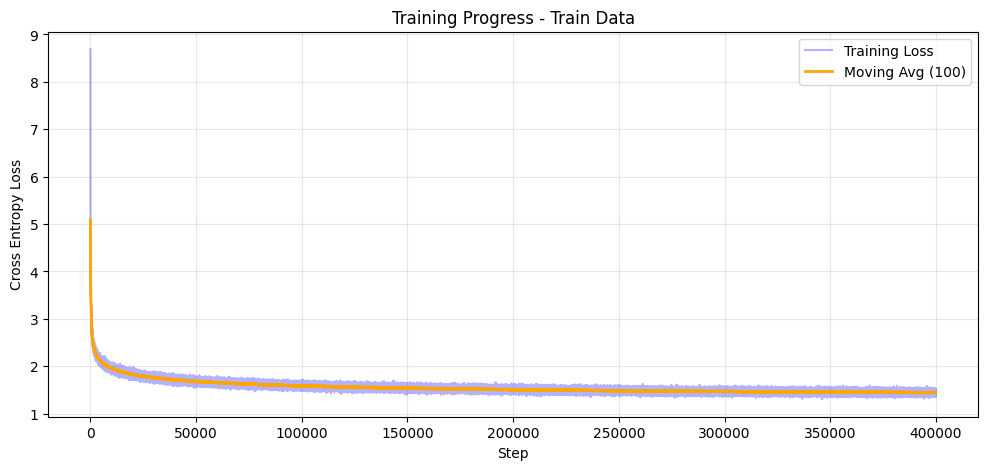

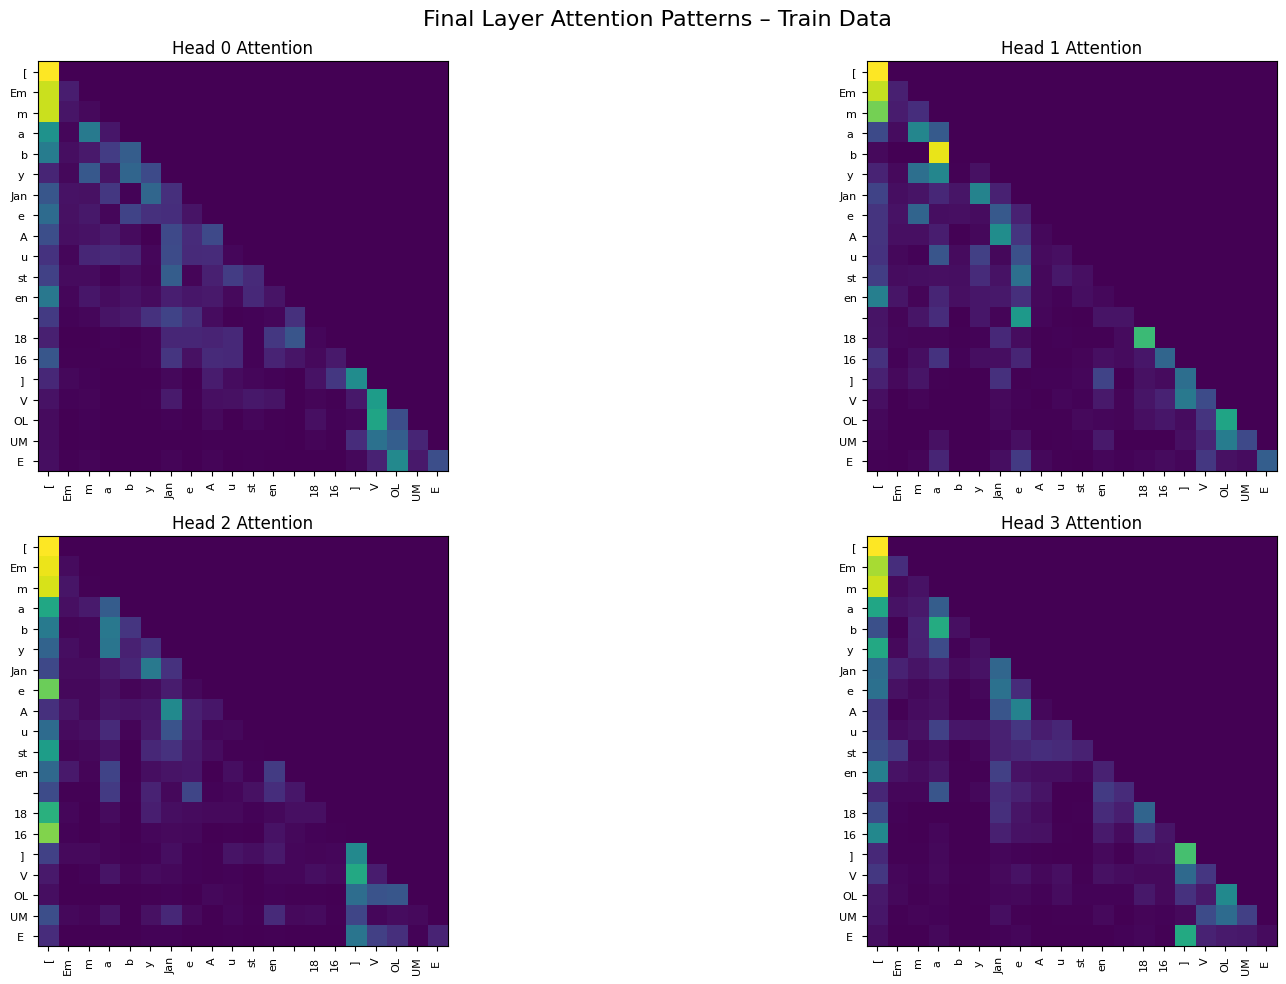

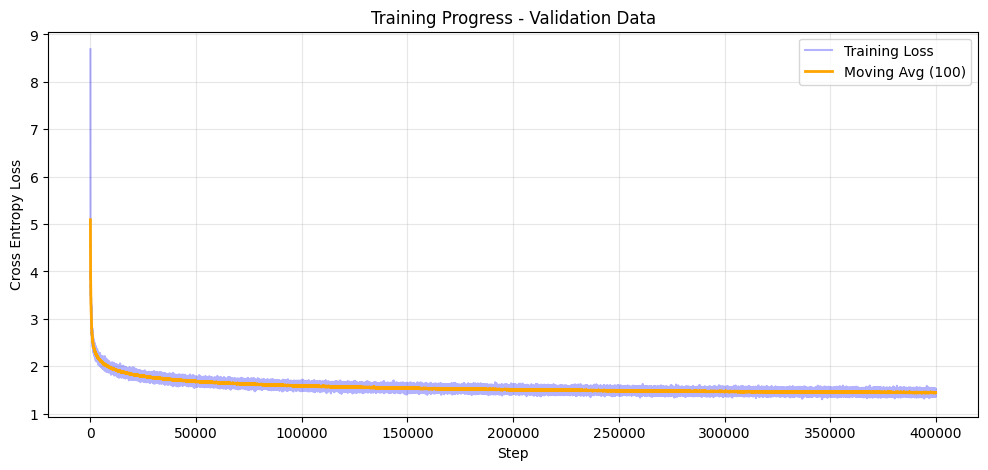

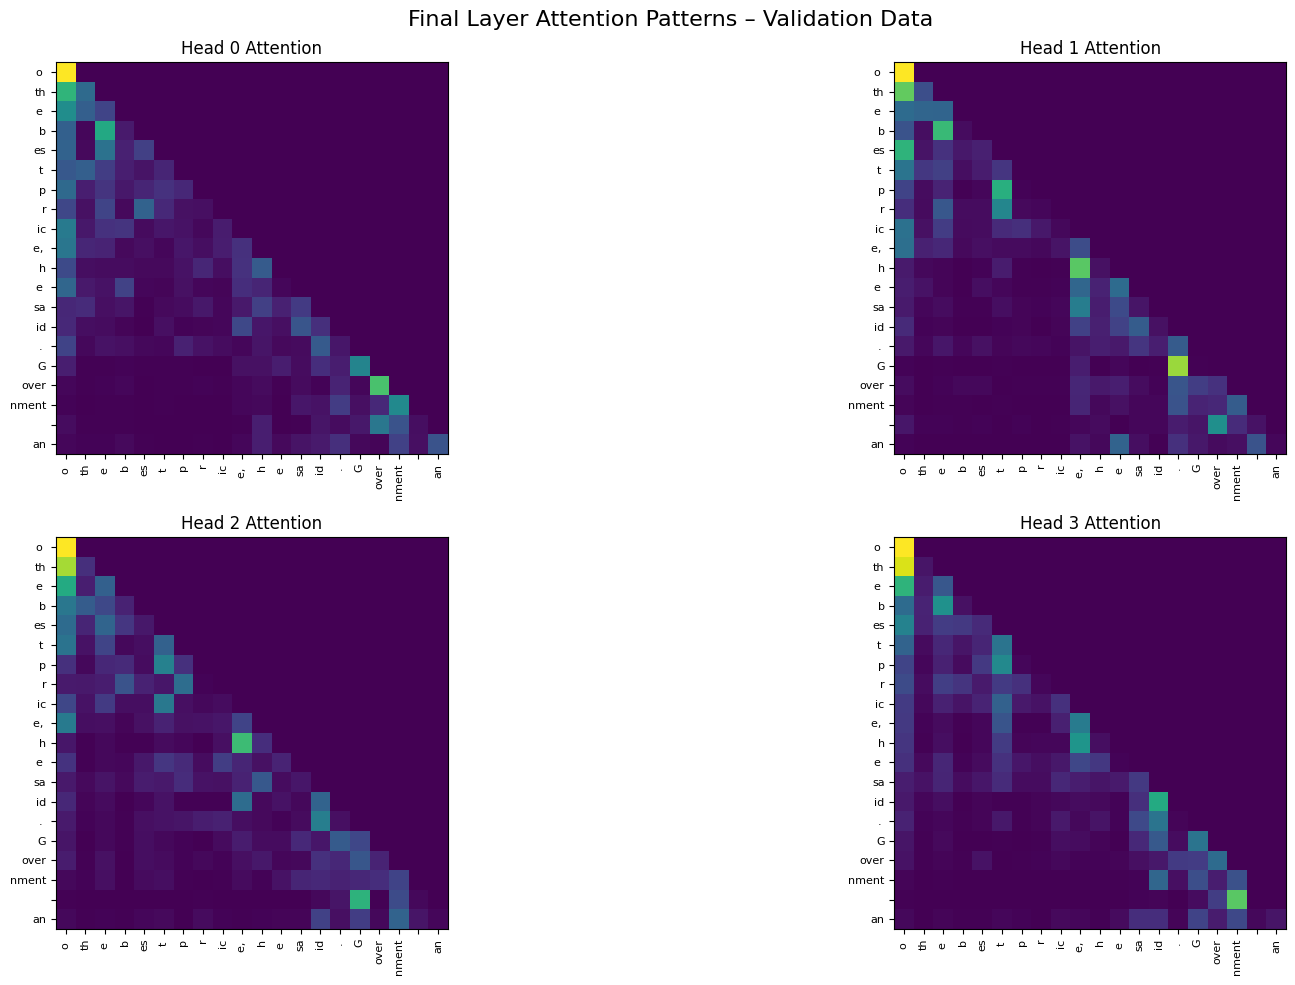

Prompt: the economy is growing because
Response: of the rise in the medium termination of the market, he said. He added that the dollar was undercutting at a huge intervention in the Gulf, which has a huge major tin producers. "These producers 
------------------------------
Prompt: and the lord said
Response: unto them, Go not into the city which I have chosen to tell them, neither said unto them, Come ye yourselves now, nor bow yourselves upon the fire, nor make you to them, neither be y
------------------------------


In [126]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F


def visualize_training_results(loss_history, model, data_tensor, tokeniser, title_suffix="Corpus"):
    """
    Visualizes training loss and attention maps for a specific corpus.
    data_tensor: A 1D tensor of BPE tokens (e.g., val_data_bpe)
    """
    
    # --- Part 1: Loss History ---
    plt.figure(figsize=(12, 5))
    plt.plot(loss_history, label="Training Loss", alpha=0.3, color='blue')

    # Add moving average if history is long enough
    if len(loss_history) > 100:
        ma = np.convolve(loss_history, np.ones(100) / 100, mode="valid")
        plt.plot(ma, label="Moving Avg (100)", linewidth=2, color='orange')

    plt.title(f"Training Progress - {title_suffix}")
    plt.xlabel("Step")
    plt.ylabel("Cross Entropy Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- Part 2: Attention Visualization ---
    model.eval()

    # Manually grab a small chunk (1 sequence) to visualize
    # We take the first BLOCK_SIZE tokens from the provided data
    ix = torch.tensor([0]) # Just start at index 0
    xb = torch.stack([data_tensor[i:i+BLOCK_SIZE] for i in ix])
    xb = xb.to(device)

    # Forward pass to get attention maps
    # Note: Ensure your model class actually has this method!
    # If not, standard 'model(xb)' won't return attention.
    try:
        with torch.no_grad():
            logits, attention_maps = model.forward_with_attention(xb)
    except AttributeError:
        print("Model does not support 'forward_with_attention'. Skipping heatmap.")
        return

    # Get last layer attention: (Batch, Heads, T, T) -> Take batch 0
    last_layer_attn = attention_maps[-1][0].cpu()
    num_heads = last_layer_attn.shape[0]

    # Decode tokens for axis labels
    # xb[0] is the tensor of IDs. We convert to list for the decoder.
    token_ids = xb[0].tolist()
    # Decode one by one to get labels
    token_labels = [tokeniser.decode([tid]) for tid in token_ids]
    
    # Limit visualization to first 20 tokens to keep heatmap readable
    view_len = min(20, BLOCK_SIZE)
    token_labels = token_labels[:view_len]

    fig, axes = plt.subplots(2, (num_heads + 1) // 2, figsize=(20, 10))
    axes = axes.flatten()

    for i in range(num_heads):
        ax = axes[i]
        # Slice attention to matches view_len
        attn_data = last_layer_attn[i, :view_len, :view_len]
        
        im = ax.imshow(attn_data, cmap="viridis")
        ax.set_title(f"Head {i} Attention")
        
        # Add word labels to axes
        ax.set_xticks(range(view_len))
        ax.set_yticks(range(view_len))
        ax.set_xticklabels(token_labels, rotation=90, fontsize=8)
        ax.set_yticklabels(token_labels, fontsize=8)

    plt.suptitle(f"Final Layer Attention Patterns – {title_suffix}", fontsize=16)
    plt.tight_layout()
    plt.show()


# --- Part 3: The Updated Coherence Test (BPE Version) ---
def ask_model(model, tokeniser, prompt, max_new_tokens=200, temperature=0.8, top_k=10):
    model.eval()
    
    # 1. Encode with BPE (Returns a list of IDs)
    input_ids = tokeniser.encode(prompt)
    context = torch.tensor(input_ids, dtype=torch.long, device=device).unsqueeze(0)
    
    print(f"Prompt: {prompt}")
    print("Response: ", end="")
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context_cond = context[:, -BLOCK_SIZE:]
            logits = model(context_cond)
            logits = logits[:, -1, :] / temperature
            
            # --- TOP-K FILTERING ---
            v, _ = torch.topk(logits, top_k)
            logits[logits < v[:, [-1]]] = -float('Inf')
            
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            
            # 2. Decode the single token ID
            # Note: next_token is a tensor [[id]]. We need the int.
            next_id = next_token.item()
            decoded_word = tokeniser.decode([next_id])
            
            print(decoded_word, end="", flush=True)
            
            context = torch.cat((context, next_token), dim=1)
    print("\n" + "-"*30)

# --- HOW TO RUN IT ---

# 1. Load the model safely
checkpoint = torch.load("best_model_bpe.pth", map_location=device)
model.load_state_dict(checkpoint["model"])

# 2. Visualize (using train/val chunks directly)
# Assuming 'train_data_bpe' and 'val_data_bpe' exist from your setup
visualize_training_results(loss_history, model, train_data, tokeniser, title_suffix="Train Data")
visualize_training_results(loss_history, model, val_data, tokeniser, title_suffix="Validation Data")

# 3. Test Generation
ask_model(model, tokeniser, "the economy is growing because", max_new_tokens=100, temperature=0.7)
ask_model(model, tokeniser, "and the lord said", max_new_tokens=100, temperature=0.7)

In [136]:
# 3. Test Generation
ask_model(model, tokeniser, """[19/11/2024, 18:19:04] Zac Wells: Hello, this is starting become weekly. I'm sorry. Could I be a pain and come to yours after work? No worries if not and I'll bring festive desserts
[19/11/2024, 18:31:18] Nick Malleson: Yeah of course, it's always a pleasure to have you over. I'll try to remember to invite you so you don't feel guilty but so far I've not been able to remember so don't hold your breath!
[19/11/2024, 18:48:44] Zac Wells: Are there any particular festive treats that are liked/hated in your house?
[19/11/2024, 20:11:12] Nick Malleson: Not really- but mince pies are always a treat
[19/11/2024, 20:11:41] Nick Malleson: So long as they're home made
[26/11/2024, 13:27:50] Nick Malleson: Fancy dinner here tomorrow? (Yes I remembered!!!)
[26/11/2024, 13:57:10] Zac Wells: I think I'm going to be working from home but thanks for remembering. I'll let you know when it's confirmed
[27/11/2024, 18:10:13] Zac Wells: Might come a bit early if there is a game of FIFA on the cards
[02/12/2024, 19:04:59] Nick Malleson: Hey. How much is Friday DD if you also pay Wednesday DD?
[02/12/2024, 19:34:32] Zac Wells: My DD is 36
[10/12/2024, 19:21:30] Zac Wells: Hello 👋, I'm having to work from the office tomorrow. Are you swimming and if so can I be cheeky and invite myself over?
[10/12/2024, 23:48:18] Nick Malleson: Sorry I'll be in hanoi! Flying tomorrow morning
[11/12/2024, 07:36:51] Zac Wells: No problem, I hope you have a great trip, see you when you get back
[11/12/2024, 08:32:47] Nick Malleson: Thanks see you in 2024
[11/12/2024, 08:32:51] Nick Malleson: 2025!
[11/12/2024, 09:37:59] Zac Wells: Yes see you in 2025!!
[07/01/2025, 17:24:07] Zac Wells: Hello, happy 2025!! Are you swimming tomorrow? I've got to be in the office so could I be rude and invite myself round
[07/01/2025, 17:38:06] Nick Malleson: Yes of course! Been ages since we've been able to thrash you at FIFA 🙂
[07/01/2025, 17:40:24] Zac Wells: Hahaha I hope you've been training. You'll need it
[08/01/2025, 13:27:18] Nick Malleson: Don't forget to put your name down
[08/01/2025, 14:18:01] Zac Wells: I'm on the list
[08/01/2025, 14:38:09] Nick Malleson: ‎Your security code with Nick changed.
[08/01/2025, 16:40:15] Zac Wells: Might need some coding help off you later. I've got a bug I just can't crack
[08/01/2025, 16:42:26] Nick Malleson: Excellent!!
[10/01/2025, 18:57:27] Zac Wells: Please can you send me that curry recipe
‎[10/01/2025, 19:01:43] Nick Malleson: ‎image omitted
‎[10/01/2025, 19:01:56] Nick Malleson: ‎image omitted
[10/01/2025, 19:02:08] Nick Malleson: Glad you liked it! Have a nice weekend d
[10/01/2025, 19:09:58] Zac Wells: You too
[14/01/2025, 18:58:20] Nick Malleson: It's complicated tomorrow. I'm going to a birthday curry for someone from work in town (although not enough time for me to actually eat, annoyingly) and head straight from there, so I guess no chance to lift share?
[14/01/2025, 18:59:11] Zac Wells: I was going to talk to you about coming over but sounds like a no. I'll see you at the pool
[14/01/2025, 20:05:22] Nick Malleson: Yeah sorry
[14/01/2025, 20:07:21] Zac Wells: Don't worry about it. Hope you have a fun time smelling the curry
‎[20/01/2025, 14:07:24] Nick Malleson: Opportunity to talk to some potential employers? ‎image omitted
[20/01/2025, 17:43:57] Zac Wells: Ooo that could be good. I'll have a look
[20/01/2025, 17:44:14] Zac Wells: Not sure if being not a student that will look good or not though
[20/01/2025, 17:52:42] Nick Malleson: Might give a bit of an idea about whats on offer though. Maybe not worth it
[20/01/2025, 19:57:58] Zac Wells: True, I'll have a think
[21/01/2025, 18:46:35] Zac Wells: Hello, this is your weekly Tuesday night text asking if I could be rude and invite myself to your house on Wednesday night before swimming
[21/01/2025, 19:55:31] Nick Malleson: Oh yeah of course, looking forward to it, see you tomorrow
[22/01/2025, 10:27:45] Nick Malleson: Did I send you this before? I did this course a few years ago and really enjoyed it. I thought he did the fundamentals of ML well in a way that I could understand most of the maths and code. Might be good if you're keen to do more ML stuff https://www.coursera.org/learn/machine-learning?specialization=machine-learning-introduction#modules (Andrew Ng is the instructor)
[22/01/2025, 10:29:14] Nick Malleson: (The course after that one gets into neural nets and random forest etc., but I don't think I actually did that one https://www.coursera.org/learn/advanced-learning-algorithms?specialization=machine-learning-introduction )
[24/01/2025, 17:16:29] Zac Wells: Swimming tonight?
[24/01/2025, 18:34:07] Nick Malleson: Nah, was tempted but over-ate fish and chips and that sealed the deal 🙂 Have fun
[24/01/2025, 22:14:15] Zac Wells: Fair, it's was pretty busy tonight.
[25/01/2025, 16:31:21] Nick Malleson: What's that electric Volvo you are wetting yourself with excitement about? The quick one. I think a mate is considering on and I want to persuade him to get it. EX maybe?
[25/01/2025, 16:31:58] Zac Wells: Ex30 dual motor
[25/01/2025, 17:44:33] Nick Malleson: 👍👍
[28/01/2025, 19:27:37] Nick Malleson: Care for dinner tomorrow?
[28/01/2025, 20:23:26] Zac Wells: That would be lovely, can I bring pudding, any requests?
[28/01/2025, 20:24:30] Zac Wells: Check out this job at University of Leeds: https://www.linkedin.com/jobs/view/4137025404
[28/01/2025, 20:24:38] Zac Wells: Guessing that's above my station
[28/01/2025, 21:06:16] Nick Malleson: Yes please! You choose. Please not stollen again though
[28/01/2025, 21:06:46] Nick Malleson: Oooh that's in my department. Ed is a good friend. What's the person spec? Does it need a PhD? Sounds stupid but I can't find the criteria on linked in
[28/01/2025, 21:08:35] Zac Wells: I've had a look. I think it's a bit over me. It looks for an advanced degree. I'm guessing that means PhD
[28/01/2025, 21:28:03] Nick Malleson: That's weird, let's look tomorrow. Normally they just say PhD. But yeah probably right
[28/01/2025, 22:01:26] Nick Malleson: https://jobs.leeds.ac.uk/Vacancy.aspx?ref=ENVGE1257 yeah needs a PhD (see candidate brief at the bottom). Good to be looking at those kinds of jobs though
[28/01/2025, 22:02:10] Zac Wells: I'm guessing it's not long till your more junior roles come up
[31/01/2025, 09:09:15] Nick Malleson: No octopush for me sadly, I need to babysit for a friend
[31/01/2025, 09:16:37] Zac Wells: Unlucky
[31/01/2025, 13:30:07] Nick Malleson: ‎Your security code with Nick changed.
[04/02/2025, 19:29:12] Nick Malleson: Can I persuade you to grace us with your presence tomorrow for dinner?
[04/02/2025, 19:51:02] Zac Wells: If love to buy I don't think I'm going to be swimming. Emily and I are off doing birthday things
[04/02/2025, 19:51:38] Zac Wells: Also I won't be working in the horforth office anymore as I've been put on garden leave before ceasing working for FCS at the end of the month
[04/02/2025, 19:52:31] Nick Malleson: Shit! Friday? You need to fill me in properly
[04/02/2025, 19:52:51] Zac Wells: Friday deffo. I'll fill you in
[04/02/2025, 19:53:30] Zac Wells: It's not too bad I'm being paid for the whole month and I've got loads of job interviews and processes on too
[04/02/2025, 19:53:37] Nick Malleson: Ok. Sorry that's really bad. I mean it'll be good in the long run but crap now.
[04/02/2025, 19:54:05] Nick Malleson: Thumbs up (can't find how to do bloody emojis on this phone!)
[04/02/2025, 19:54:32] Zac Wells: I feel really relieved weirdly. Yesterday I was angry but today I see the the silver lining and think it'll be really good for me.
[04/02/2025, 19:54:44] Zac Wells: I'll fill you in on all the job prospects too on Friday
[04/02/2025, 20:36:50] Nick Malleson: Yeah it definitely will be
[04/02/2025, 20:37:15] Nick Malleson: 👍👍👍 found them!
[04/02/2025, 20:38:36] Zac Wells: 👍👍👍👍
‎[05/02/2025, 13:18:44] Nick Malleson: Happy birthday! Your present is a 1 month Coursera subscription. They don't do vouchers so chatgpt has kindly done one for you. Sign up now and I'll just give you cash on Friday. Figured this month is a good one to grind some courses and slay your next interview ‎image omitted
[05/02/2025, 14:03:17] Zac Wells: Are you sure? You're way too nice
[05/02/2025, 15:33:21] Nick Malleson: Absolutely! Here are some cards that are more suitable to your age (apparently)
‎[05/02/2025, 15:34:29] Nick Malleson: ‎image omitted
‎[05/02/2025, 15:36:04] Nick Malleson: ‎image omitted
[05/02/2025, 15:37:49] Zac Wells: It's amazing. Hove you tried the deep sink
‎[05/02/2025, 15:39:42] Zac Wells: ‎image omitted
[05/02/2025, 15:50:55] Nick Malleson: The Chinese one? No is it good? I've heard it is
[06/02/2025, 14:55:58] Zac Wells: Think I'll try get to this if I've not found anything by then
[06/02/2025, 15:34:52] Nick Malleson: Remind me when it is? (I lost my WhatsApp again on recent phone replacement (
[06/02/2025, 15:35:15] Zac Wells: 17th march
[07/02/2025, 13:27:54] Nick Malleson: Currently me v.s. you in octopush!
[07/02/2025, 13:28:12] Zac Wells: Thatll be fun
[07/02/2025, 13:28:41] Nick Malleson: I have to confess, that wasn't my first thought ....
[07/02/2025, 13:28:57] Zac Wells: Hahaha
[10/02/2025, 11:23:20] Zac Wells: Am I still alright to caj a lift off you?
[10/02/2025, 11:47:39] Nick Malleson: Yeah of course, we just need to go round the ringroad. Gildersome is only a small diversion. Do you want dinner ? At least come early so we can get a game of FIFA in
[10/02/2025, 11:48:54] Zac Wells: Dinner would be lovely. FIFA for definite! I'll update you on the job hunt
[10/02/2025, 11:49:27] Nick Malleson: Excellent
[10/02/2025, 11:50:32] Zac Wells: Just checked, I need to be at the pool early so that might be a spanner 🔧 in the works  🏭
[10/02/2025, 11:55:18] Nick Malleson: What time? Getting their early isn't necessarily a problem
[10/02/2025, 11:55:48] Zac Wells: Emma said 7:45 but I think I could probably be flexible with that and blame traffic
[10/02/2025, 11:56:30] Nick Malleson: Yeah that's too early! Could you push it to 8 latest?
[10/02/2025, 11:56:46] Nick Malleson: Blame me :-)
[10/02/2025, 12:35:28] Zac Wells: I'll do that :)
[12/02/2025, 17:45:45] Nick Malleson: Meg says any chance you could get some lemons on your way?
[12/02/2025, 17:47:57] Zac Wells: Will do
[17/02/2025, 10:19:49] Nick Malleson: I need 2 rear tyres what do you recommend? Main thing I care about is they are efficient for the battery range
[17/02/2025, 10:20:40] Zac Wells: You've had the EV Michelin tyres before haven't you. I think Id do the same. I think they are call primacy?
[17/02/2025, 10:21:30] Nick Malleson: Can't remember but if you've not heard about some fancy new ones on the socials I should have then I'll get same again
[17/02/2025, 10:22:33] Zac Wells: I've not sadly. I'm not as hot on tyres as I was
‎[17/02/2025, 10:31:41] Nick Malleson: What do you reckon the difference with all these is? I reckon I have one of the circled ones because it says '92H' on the receipt. (But very little else). Choose for me Zac! ‎image omitted
[17/02/2025, 10:32:38] Nick Malleson: Def e.primacy in there now
[17/02/2025, 10:33:09] Zac Wells: One is probably designed for EV. Probably a bit harder compound and more efficient
[17/02/2025, 10:33:19] Zac Wells: The e.primacy that is
[17/02/2025, 10:33:22] Zac Wells: Google it?
[17/02/2025, 10:33:54] Nick Malleson: Yeah I was hoping you'd do that for me :-) It's ok I'll get the same as I did a bit of research last time and they seemed good
[17/02/2025, 10:41:38] Zac Wells: Just read tyrereviews.com and it looks good
‎[17/02/2025, 10:41:58] Zac Wells: ‎image omitted
[17/02/2025, 10:42:11] Nick Malleson: Phew cause I complete the order 30s ago . Thanks for checking
[17/02/2025, 10:42:48] Nick Malleson: Oh nice, 3rd. They were 7th in the thing I quickly looked at now but their test didn't seem very thorough tbh I reckon it was more like click bait
‎[17/02/2025, 16:10:07] Zac Wells: What are you thoughts, its not a Toby but could still be fun ‎image omitted
[17/02/2025, 17:47:16] Nick Malleson: Yeah why not. A pizza will be damn nice afterwards. I'm driving on Sunday right?
[17/02/2025, 17:47:33] Zac Wells: If that works for you
[17/02/2025, 17:49:08] Nick Malleson: Well you know me. I'm not too bothered either way but you're young and enthusiastic so I'm sure you want to go
[17/02/2025, 17:49:38] Zac Wells: I've signed us up
[19/02/2025, 11:24:55] Nick Malleson: Crap I just realised I don't have a car tonight. Any chance of a lift. I won't offer dinner as I may work a bit later as the family are away tonight (hence no car)
[19/02/2025, 11:25:47] Zac Wells: Yeah no problem give the lift. I was going to get in touch about tea because Emily is here so going to eat before coming to you.
[19/02/2025, 11:47:37] Nick Malleson: Awesome! Thanks see you later
[20/02/2025, 12:36:18] Zac Wells: B team meal is looking like it'll be 6pm
[20/02/2025, 18:08:35] Nick Malleson: Are you going? Not sure Im going to hang around. Fine if you want to though I can get home
[20/02/2025, 18:13:20] Zac Wells: I'm not sure, I might not bother. I know you don't want to go and the other people going aren't that fun
[23/02/2025, 07:45:44] Nick Malleson: ETA 8:06
[23/02/2025, 07:49:40] Nick Malleson: Don't suppose I could have a piece of toast in The Journey.
[23/02/2025, 07:50:05] Zac Wells: Of course, just butter or jam too? We've got raspberry jam
[23/02/2025, 07:50:47] Nick Malleson: Call raspberry jam would be lovely. Thank you.
[23/02/2025, 09:07:50] Nick Malleson: Check out this 1 bedroom house for sale on Rightmove
https://www.rightmove.co.uk/properties/158407349?utm_campaign=property-details&utm_content=buying&utm_medium=sharing&utm_source=whatsapp#/&channel=RES_BUY
[23/02/2025, 18:07:44] Zac Wells: Virdee
[26/02/2025, 09:59:24] Nick Malleson: Dinner tonight? Not sure what it'll be but surely can't be worse than the frozen pizza debacle
[26/02/2025, 10:36:57] Zac Wells: Sounds great, I can bring something if you want
[26/02/2025, 11:17:36] Nick Malleson: I tell you what, I'll raid the freezer when I get home and let you know if we're short of anything crucial?
[26/02/2025, 11:19:35] Zac Wells: Sounds good
[28/02/2025, 16:45:43] Zac Wells: Just got the consultant job 😀
[28/02/2025, 16:46:12] Nick Malleson: Amazing!!!! You're taking it?
[28/02/2025, 16:46:35] Zac Wells: Yeah man, 5k more than Morrisons too
[28/02/2025, 16:47:08] Nick Malleson: Sweet! Such a good silver lining to being fired from that crappy job
[28/02/2025, 16:47:09] Nick Malleson: Celebrate
[28/02/2025, 16:49:27] Zac Wells: I know right, get fires and then get a 15k pay rise. Literally lost  a week's wage which I'll recoupe within my first month at the new place
[03/03/2025, 14:23:37] Nick Malleson: You've been looking at monitors recently. Which one should I get? Needs to be big and good quality but not too expensive (work will pay but it comes out of my account so means I can't spend it on other things). I'd rather have one good size one than two smaller ones, but that's an option too
[03/03/2025, 14:26:48] Zac Wells: I bout a big curved dell, think it was about 250. I'll see if I can find a link. 32"
[03/03/2025, 14:26:54] Zac Wells: What are you getting it for.
[03/03/2025, 14:27:07] Zac Wells: Also just ordered a Mac mini, should arrive Wednesday
[03/03/2025, 14:28:00] Zac Wells: Look at this product that I found on google.com https://g.co/kgs/GrHV5fB
[03/03/2025, 14:30:10] Nick Malleson: Thanks, not sure it will be big enough though. May have to go into a shop to look and get an idea of their sizes
[03/03/2025, 14:30:17] Nick Malleson: Amazing!
[03/03/2025, 14:34:45] Zac Wells: Th is pretty big, quite comfortably get two pretty much full size windows next to each other. What are you doing with it?
[03/03/2025, 14:36:47] Nick Malleson: OK, maybe it'll be fine. I'll find someone with a similar size to see. The price and picture quality both look really good. Sadly it'll mostly be used for rubbish, but I want it to be big enough for programming when I do occasionally get an opportunity to do that (ideally three windows wide, but two might be fine)
[03/03/2025, 14:37:28] Zac Wells: Yeah you need one like the one you've got a home for 3 I recon
[05/03/2025, 10:10:15] Zac Wells: Hark! Good morrow! Dost thou plan to partake in the aquatic realm this eve?
[05/03/2025, 10:19:32] Nick Malleson: Ah, noble companion! Verily, I shall immerse mine mortal form within the briny depths anon, to engage in the most esteemed sport of Octopush! But lo! I extend unto thee an invitation most gracious—wouldst thou deign to grace mine humble hall and partake of a feast most bounteous ere we descend into yon watery fray? Pray, let thine answer be swift, lest the fates conspire against our merry revelry!
[05/03/2025, 10:21:24] Zac Wells: Gladly accept, I do! A feast most bounteous, a delight it shall be. Bring a dish most worthy, I shall—perhaps a treat to please all gathered. Await our revelry, I do, with great eagerness!
[07/03/2025, 17:41:09] Zac Wells: Are you swimming tonight?
[07/03/2025, 18:08:51] Nick Malleson: Yeah!
[07/03/2025, 18:09:07] Zac Wells: Sick see you at yours
[12/03/2025, 08:00:35] Nick Malleson: Everyone is disappointed that you can't make it tonight. At first Jacob was just sad because he wants to show you his new Lego space plane thing, but then it dawned on him that you wouldn't be being pudding either and now he's doubly sad
[12/03/2025, 08:02:13] Zac Wells: Hahaha 🤣🤣🤣 love the double sad reason. I'll be swimming on Friday so he'll have to show me the Lego then
[12/03/2025, 08:02:40] Zac Wells: You'll have competition I'm getting Indian from a client for tea
[12/03/2025, 08:09:36] Nick Malleson: Argh jealous. I can't make Friday my dad's up
[12/03/2025, 08:21:00] Zac Wells: AHH, bin him off, you can see him at the weekend 😜
[19/03/2025, 09:45:09] Zac Wells: Shame about you not swimming tonight. I'll have to catch-up about work on Friday assuming you're down
[19/03/2025, 10:55:36] Nick Malleson: Yeah definitely. Good chance I can make it on Fri. Excited to hear new job gossip
[19/03/2025, 10:56:08] Zac Wells: There's not much gossip really. It's great. They are all really nice!
[21/03/2025, 16:06:23] Nick Malleson: Do you want to come over for dinner before hockey? I'm contemplating fish and chips, but may resort to mundane pasta
[21/03/2025, 16:07:07] Zac Wells: I promised Emily that I'd make Bolognese but I'll try and be there a bit early to fill you in.
[21/03/2025, 16:07:18] Zac Wells: I think if I played after fish and chips I'd drown
[21/03/2025, 16:08:41] Nick Malleson: Sensible choice! Come over whenever
[21/03/2025, 16:13:33] Zac Wells: Will do
[25/03/2025, 17:28:09] Zac Wells: bonsoir, tu es allé nager ce mercredi soir mon ami?
[25/03/2025, 17:31:23] Nick Malleson: Keh?!?
[25/03/2025, 17:31:40] Nick Malleson: (You need to say that in the voice of Manuel from Faulty Towers)
[25/03/2025, 17:35:40] Zac Wells: Hhahaha. That reference is before my time but I've googled it.
[25/03/2025, 17:48:58] Nick Malleson: I did German GCSE so no idea what you're talking about. In other news do you fancy coming for dinner tomorrow before hockey?
[25/03/2025, 17:50:57] Zac Wells: That would be lovely, I'm in Manchester during the day so I'll come direct. I mush remember to grab my trunks
‎[01/04/2025, 16:29:13] Nick Malleson: Fancy sharing a lift to this? I asked Jo and said we should come if we can ‎image omitted
[01/04/2025, 21:46:49] Zac Wells: Sadly I'm not free, we're out in Leeds for Emily's bday. You should go
[02/04/2025, 07:19:53] Nick Malleson: Dinner later? I think it'll be crap pizza but I'll send Jacob to get them so at least there will be enough
[02/04/2025, 11:42:50] Zac Wells: Dinner is a no, Emily is here because she's not feeling great but I may be early so there might be some FIFA time if that's available
[02/04/2025, 11:47:03] Nick Malleson: Bring pudding too :-)
[02/04/2025, 13:50:03] Zac Wells: We shall see?
[02/04/2025, 16:42:42] Nick Malleson: https://www.electrifying.com/blog/article/new-byd-platform-promises-1-000kw-ultra-rapid-charging-but-ccs-limitations-rule-it-out-for-european-drivers
[02/04/2025, 16:47:12] Zac Wells: I'll have to move to China
[04/04/2025, 13:29:08] Nick Malleson: You down tonight? I have my name on the list. I'll need to leave at 7ish because I want to swap over monitors at work ideally (although not important if I do it another day)
[04/04/2025, 14:52:44] Zac Wells: Planning to be down tonight, I can try for 7ish but I don't want to promise just incase
[04/04/2025, 14:54:11] Nick Malleson: No worries. Let me know when you set off, if you're likely to be here by 7 I'll pack up my screen, if not then I won't!
[04/04/2025, 14:54:22] Zac Wells: Will do!
[04/04/2025, 18:28:35] Zac Wells: Just leaving home
[04/04/2025, 18:28:47] Zac Wells: ‎This message can't be displayed here. Please open ‎WhatsApp on your phone to view the message.
[04/04/2025, 18:50:41] Nick Malleson: Nice one. Car's open
‎[04/04/2025, 19:22:22] Zac Wells: ‎image omitted
[09/04/2025, 10:03:24] Nick Malleson: Diner tonight?
[09/04/2025, 10:03:48] Nick Malleson: Oh no ignore me, I've remembered you're away
[09/04/2025, 10:03:52] Nick Malleson: Have fun!
[09/04/2025, 10:04:12] Zac Wells: You're right, I'll be in Chester and then Wales. Next week :)
[15/04/2025, 08:27:56] Zac Wells: Hello, I was wondering if I could be cheeky tomorrow and request tea? I'm showing our house at about 6 so I should get to you at about 7 so I know that's later than you normally eat. No problem if not or your not swimming.
[15/04/2025, 08:44:29] Nick Malleson: Yeah no worries at all. Show the crap out of that house. (Hmm,  not sure that works, but whatever). We'll save you something. Pasta? I'm guessing nothing too heavy
[15/04/2025, 09:01:12] Zac Wells: Yeah whatever, you know me iron stomach
[15/04/2025, 09:01:47] Nick Malleson: Urgh god not like Stollen Gate
[15/04/2025, 17:59:57] Zac Wells: Just accepted an offer on the house so I think I'll be on normal time
[15/04/2025, 18:07:58] Nick Malleson: Woo hoo!!!! Looking forward to the dinner chat :-)
[15/04/2025, 18:35:05] Zac Wells: I'll update you
[16/04/2025, 12:57:04] Zac Wells: Here Ye, Here Ye! The house has sold so I will be normal time! Here Ye, Here Ye! 🔔
‎[17/04/2025, 06:40:31] Nick Malleson: You were talking about the top one yesterday ‎image omitted
[22/04/2025, 18:10:55] Zac Wells: I found this property on the Rightmove Android app and wanted you to see it: https://www.rightmove.co.uk/properties/160218023
[22/04/2025, 18:11:15] Zac Wells: We've just put in an offer on this which has been accepted. You'll have to show Megan
[22/04/2025, 19:55:44] Nick Malleson: Oh wow!!!! That's really exciting . Great area. House looks amazing. I'll tell meg as soon as she's finishes reading with tobes. If my train is ok do you want to come to dinner on Fri before octopush?
[22/04/2025, 19:57:30] Zac Wells: Were on our final weekend away of 3 so no hockey for me on Friday sadly. Wednesday deffo though if you're around
[30/04/2025, 05:16:08] Zac Wells: Good morn, ist thou swimming tonight?
[30/04/2025, 07:11:43] Nick Malleson: Yeah! Are you coming for dinner first? We need to hear about the house
[30/04/2025, 07:24:57] Zac Wells: You twisted my arm, I'll be there! I'll show you everything with it.
[30/04/2025, 21:48:00] Zac Wells: https://open.spotify.com/episode/0ASIHszSg67DQycdScIsDF?si=xlFHFusdRWyh0PpK_Fc2nA
[02/05/2025, 17:11:46] Zac Wells: Are you swimming tonight. Your on the waiting list
[02/05/2025, 18:41:59] Nick Malleson: Oh crap no. Will remove myself
[02/05/2025, 18:42:26] Nick Malleson: Not sure how that happened
[02/05/2025, 18:43:21] Nick Malleson: Looks like there is still 5 a side
[02/05/2025, 18:43:33] Zac Wells: Yeah I think it'll be fine
[07/05/2025, 05:40:15] Zac Wells: Good morning, it's thou swimming this fine eve?
[07/05/2025, 07:49:45] Nick Malleson: Indeed good sir! I'll have Megans cousin John who wants to try it out too so we may have a full car if the kids come too
[07/05/2025, 07:50:46] Nick Malleson: Oh and pls come for dinner. I was assuming you would. It'll be baige today
[07/05/2025, 07:54:23] Zac Wells: Sounds good :)
[08/05/2025, 12:46:46] Nick Malleson: I love these articles by Hannah Richie. Good careful simple impactful data analysis https://www.sustainabilitybynumbers.com/p/carbon-footprint-chatgpt?publication_id=1199196&post_id=162892345&isFreemail=true&r=2a74k0&triedRedirect=true (plus this one in particular is something that annoys me loads; when people worry about pointless things instead of thinking about driving and flying which are the real problems)
[09/05/2025, 11:22:34] Nick Malleson: How about a bit of bleep test tonight? I think I'll join in
[09/05/2025, 11:51:53] Zac Wells: Deffo for the swim, we will see about bleep
[09/05/2025, 11:56:17] Nick Malleson: Lazy!
[09/05/2025, 18:08:00] Nick Malleson: Crap. Pressure's on. Dave's kids are doing the bleep test. If they beat me I'll never hear the end of it
[09/05/2025, 18:51:44] Zac Wells: Might be 5 minutes late, but ll let you know
[13/05/2025, 19:25:54] Zac Wells: Shall I behold thee at the swimming centre tomorrow night, my good friend?
[13/05/2025, 19:50:56] Nick Malleson: Verily! And perhaps I could press upon you through gift of a feast before we depart?
[13/05/2025, 20:26:24] Zac Wells: Hark, a feast! How couldth I protest. Thy will be there!
[20/05/2025, 21:15:48] Nick Malleson: Will you join us for dinner tomorrow? It'll be baige! Oh wait is this the week you're skiving?
[20/05/2025, 21:28:54] Zac Wells: This week I'm not skiving, that was Friday. I would love to join you for tea and I'll make sure I've got pudding. Don't want to be in the dog house 2 weeks in a row
[20/05/2025, 22:44:58] Nick Malleson: Make it a good one :-)
[20/05/2025, 22:46:25] Zac Wells: Stollen it is!
[21/05/2025, 17:32:08] Zac Wells: Beat you to your house
[23/05/2025, 13:36:18] Zac Wells: Swimming tonight?
[23/05/2025, 13:52:54] Nick Malleson: Yeah I'm on the list. You're welcome to join us for left overs on the way
[23/05/2025, 13:53:00] Nick Malleson: (food that is)
[23/05/2025, 14:38:48] Zac Wells: Don't think I'll me leftovers but I'm definitely down for a lift
[23/05/2025, 16:51:55] Nick Malleson: I'm worried about tonight. It's not the kind of game I can play without a sub.
‎[28/05/2025, 15:33:17] Nick Malleson: Gutted. He upsold me on the convertible mini cooper but we literally couldn't get into it so had to revert to the fine but boring standard one. Everyone was very disappointed ‎image omitted
[28/05/2025, 18:11:38] Zac Wells: How sad, that is disappointing
[03/06/2025, 20:21:18] Zac Wells: Hello, are you swimming tomorrow? If so could I make the usual pudding trade
[03/06/2025, 22:06:55] Nick Malleson: Yes of course, Toby was already asking about FIFA earlier :-)
[04/06/2025, 07:25:28] Zac Wells: Brilliant, that's so funny he's already asked about fifa
‎[04/06/2025, 11:38:35] Nick Malleson: Got the mac mini working hard on a neural network today. You can hear the fan going and everything ‎image omitted
[04/06/2025, 11:40:19] Zac Wells: Wow, mine crashed on me the other day due to memory load issues with my reinforcement stocks model
[04/06/2025, 11:44:51] Nick Malleson: Yeah python can do that sometimes. It will use all the memory it can. Java uses virtual machines so if the memory use hits a pre-defined limit then the program crashes, not the OS. I'm not sure what you can do about it other than being careful and killing the python process before the whole thing becomes unusable
[04/06/2025, 11:47:57] Zac Wells: It was just doing a parameter sweep of some RL models and I wasn't really watching it as it was while I was at work
[04/06/2025, 17:18:00] Zac Wells: https://github.com/ZacUWH/Python-Projects/tree/main/quant%20ml
[08/06/2025, 11:52:04] Zac Wells: match report for you from the weekend. We lost all of our games however; we played better throughout and scored 2 goals. We kept SouthSea A to 8-0 over 20 minutes so thats pretty good too. Yorkshire A got the final after beating SouthSea A in the semi final but they were then beat by TSW A on the final. they were very upset
[08/06/2025, 11:53:26] Zac Wells: In other news, my trading model has just returned a profit of 25K over 4 years in its training - still need to test it to see if the model is just overfitting or if its really that good
[08/06/2025, 14:45:43] Nick Malleson: Well done! Can't believe A didn't win though. Isn't it usually Southsea that they lose to in the final?
[08/06/2025, 14:46:02] Nick Malleson: Nice!
[10/06/2025, 14:22:51] Zac Wells: I’m guessing this I’ll need a PHD for this, the Leeds uni ones aren’t that clear

https://www.linkedin.com/jobs/view/4247534321
[10/06/2025, 15:00:07] Nick Malleson: Sorry my internet is so shit on this train I can't check. Can you get to the source listing on leeds.ac.uk or jobs.ac.uk? It will say it on there. LinkedIn try really hard to hide how to het to the souirce!
[10/06/2025, 15:00:50] Nick Malleson: I did spot this one though, again may need a PhD but if not Born in Bradford is really awesome  https://uk.linkedin.com/jobs/view/senior-research-fellow-–-3-years-at-born-in-bradford-4176596736?refId=lIjXD2IP1vQZPniK01E0og%3D%3D&trackingId=MlMbP5K31mfCJUKt6g4mZQ%3D%3D
[11/06/2025, 18:22:52] Zac Wells: The house mortgage has been approved so we're on. I'll look at that job again, I think it wanted a PhD
[11/06/2025, 18:57:26] Nick Malleson: Oh that's great news! You'll have a job in no time. Really annoying but in a few weeks it'll be a minor blip. We'll talk about PhDs as well next week. I was thinking about that a bit. Shit money but fun.
[11/06/2025, 19:00:12] Zac Wells: It is great news, just a shame it's taken such a long time to sort. We should talk about PhDs, just money that's the problem with them
‎[15/06/2025, 08:59:40] Nick Malleson: ‎image omitted
[15/06/2025, 09:00:23] Nick Malleson: Vintage car racing on the beach in Briglington. If you're free you should come down. We're here for junior football tournament
[15/06/2025, 09:11:06] Zac Wells: That's pretty cool, we're not free but make sure you soak it all in.
‎[15/06/2025, 09:11:43] Nick Malleson: It's such a random thing to do ‎image omitted
[15/06/2025, 09:11:45] Zac Wells: The sad truth is the Mazda is probably alot faster than Ol' Red
[15/06/2025, 09:11:56] Zac Wells: Super cool
‎[15/06/2025, 09:12:36] Nick Malleson: ‎image omitted
[15/06/2025, 09:12:43] Nick Malleson: Ok I'll stoo now :-)
[15/06/2025, 09:13:25] Zac Wells: So cool, you don't have to stop if you've got more. The Bonneville express looks fast
[15/06/2025, 09:16:29] Nick Malleson: If you're sure.
[15/06/2025, 09:16:42] Nick Malleson: Text STOP if you wish to no longer receive these messages
‎[15/06/2025, 09:16:49] Nick Malleson: ‎image omitted
‎[15/06/2025, 09:25:59] Nick Malleson: Listen to this one! ‎video omitted
[15/06/2025, 09:26:01] Nick Malleson: And that was just idling
[15/06/2025, 10:54:34] Nick Malleson: Get ready for a slam.
[15/06/2025, 10:54:42] Nick Malleson: It may be some time though the internet here is dubious
[15/06/2025, 11:01:48] Nick Malleson:
‎[15/06/2025, 11:01:54] Nick Malleson: ‎image omitted
‎[15/06/2025, 11:02:07] Nick Malleson: ‎image omitted
‎[15/06/2025, 11:02:08] Nick Malleson: ‎image omitted
‎[15/06/2025, 11:02:08] Nick Malleson: ‎image omitted
‎[15/06/2025, 11:02:09] Nick Malleson: ‎image omitted
‎[15/06/2025, 11:02:10] Nick Malleson: ‎image omitted
‎[15/06/2025, 11:02:11] Nick Malleson: ‎image omitted
‎[15/06/2025, 11:02:13] Nick Malleson: ‎image omitted
‎[15/06/2025, 11:02:14] Nick Malleson: ‎image omitted
‎[15/06/2025, 11:02:14] Nick Malleson: ‎image omitted
‎[15/06/2025, 11:11:39] Nick Malleson: ‎image omitted
[18/06/2025, 08:10:42] Zac Wells: The cars look classy. Sorry it's taken ages me me to reply we were at Emily's dad's where they have no signal
[18/06/2025, 08:10:50] Zac Wells: Are you swimming this fine eve?
[18/06/2025, 08:13:21] Nick Malleson: Oh that's ok I wasn't expecting a reply to my spam. Yeah definitely, would you like to join us for dinner?
[18/06/2025, 08:13:45] Zac Wells: If that's ok, I'll bring the pudding
[18/06/2025, 08:14:03] Nick Malleson: 👍👍
[19/06/2025, 15:09:00] Zac Wells: I’ve put my name in for that ASDA job. I’ll have to swatt up with you if it goes any further
[19/06/2025, 16:44:40] Nick Malleson: Good stuff. Yeah lets do that. By the way I think this is the kind of thing you should go for if you're willing to sacrifice the salary for the sweet academic life https://jobs.lse.ac.uk/Vacancies/W/4850/0/452800/15539/research-assistant-pre-doc-environmental-economics-and-innovation (this one does need a masters I think, but that may be negotiable, and in London so quite a commute, but I reckon you'd be a good candidate for this kind of role)
[25/06/2025, 10:40:12] Zac Wells: swim?
[25/06/2025, 10:41:39] Zac Wells: Also that job I think is looking for a research background rather than industry. I’ll update you on processes tonight. I’ve got 3 interviews this week
[25/06/2025, 11:07:09] Nick Malleson: Sorry not tonight, I'm in London for a conference. Good luck with the interviews! You'll have another in no time
[25/06/2025, 11:07:10] Nick Malleson: No Friday this week?
[25/06/2025, 11:11:11] Zac Wells: Thanks mate, hopefully it’ll all be sorted soon!
[25/06/2025, 11:11:16] Zac Wells: Enjoy London!
[25/06/2025, 11:11:45] Zac Wells: I don’t think there is any swimming again on Friday 🙁 I don’t think I’ll see you before I go to Italy now
[25/06/2025, 11:12:21] Nick Malleson: Rubbish! How long will you be in Italy for?
[25/06/2025, 11:12:40] Zac Wells: 2 weeks, were back Mid-July
[25/06/2025, 11:12:44] Zac Wells: 18th I think
[30/06/2025, 17:18:18] Nick Malleson: Another reason to get an EV: https://www.youtube.com/watch?v=Q5JQySb9_FY . That would be a stupid idea if you had to leave a petrol engine running over night but seems like a great idea for an EV. Will try it this evening ‎<This message was edited>
[30/06/2025, 17:20:40] Zac Wells: A great idea, I don’t see why anyone would ever have a proper aircon unit. I’ll just suffer
[04/07/2025, 12:31:20] Nick Malleson: Been running those data science interviews all week. Got some great advice for your next interview. A real gem today was an answer to the question "how does a random forest work": "it uses randomness to get the best out of your data"
[04/07/2025, 12:37:43] Zac Wells: Love that response, not entirely wrong but missing some key info
[04/07/2025, 12:39:35] Zac Wells: I've also got a new job, I'm going to be working for Morrisons on their home delivery product using data to optimise delivery. They are very interested in using AI to solve it
[04/07/2025, 12:57:10] Nick Malleson: Oh nice! Did you interview from holiday? That's great news
[04/07/2025, 13:15:41] Zac Wells: Yeah I had one late last week and then another on Tuesday, got the offer on Wednesday
[04/07/2025, 13:15:52] Zac Wells: I interviewed from home
[09/07/2025, 07:51:51] Nick Malleson: Good morning!! Nice holdls? Remind me, are you around tonight?
[09/07/2025, 08:16:21] Zac Wells: Very nice holiday so far, still away so you won't be seeing me tonight. Next week maybe depending on flights.
‎[09/07/2025, 08:16:54] Zac Wells: ‎image omitted
[09/07/2025, 08:17:12] Zac Wells: Not quite ponds forge for swimming but the weather is alot better
[09/07/2025, 08:23:49] Nick Malleson: So jealous
[16/07/2025, 07:20:12] Nick Malleson: Dinner tonight?
‎[16/07/2025, 07:20:41] Nick Malleson: My finger got bashed on Monday so I may be left handed. If you have a spare glove could I borrow it? ‎image omitted
[16/07/2025, 07:30:51] Zac Wells: I have got a spare glove but im probably not swimming. We only land at 4:30
[16/07/2025, 07:53:08] Nick Malleson: Oh no! But we've got so much to catch up on!
[16/07/2025, 08:30:31] Zac Wells: I know, Friday?
[16/07/2025, 08:32:57] Nick Malleson: Can't, will be on the way to the junior nationals
[16/07/2025, 08:33:22] Nick Malleson: Well if you're early come for a swim anyway even if you can't go via my house
[16/07/2025, 08:50:51] Zac Wells: Oh no, it might have to be next Wednesday then, hopefully soon!
[22/07/2025, 18:16:57] Zac Wells: Yo yo yo, is you swimming tomoz?
[22/07/2025, 18:18:17] Nick Malleson: Yeah! But I'm sorry I can't invite you to tea. Meg has a shit load of family over. Come for 7 for a game of fifa if you can though
[22/07/2025, 18:19:13] Zac Wells: No worries, I'll come after tea and fill you in on all the goings pn
[22/07/2025, 19:30:18] Nick Malleson: Excellent
[22/07/2025, 19:30:47] Nick Malleson: Bring pudding
[23/07/2025, 15:56:19] Nick Malleson: Megan now says there is too much food. Please could you come and help us eat it. Also, NO PUDDING! Apparently we have too much of that also
[23/07/2025, 17:17:38] Zac Wells: Of course I can help you eat it, I'll be there soon. I'll let you know when I leave
[23/07/2025, 17:21:07] Zac Wells: Just left should be with you about 6:00, maybe slightly before.
[23/07/2025, 17:41:49] Nick Malleson: Park behind the car on the drive. If you get close you won't block anyone
[23/07/2025, 17:42:47] Zac Wells: Will do
[29/07/2025, 18:45:42] Zac Wells: Hello, it's thou visiting the piscine tomorrow evening?
[29/07/2025, 19:21:36] Nick Malleson: Yes indeed! Please come but be warned it'll be rushed boring pasta I'm afraid.
[29/07/2025, 19:24:10] Zac Wells: There will be pudding though, is there anything else I can bring?
[29/07/2025, 19:25:04] Nick Malleson: Pudding will be perfect! There's a small chance that Megan may not be home in time with the car, so having you as a backup will be amazing too (it's fine if we have to leave the kids at home for a bit if she's delayed)
[29/07/2025, 20:11:45] Zac Wells: Ok cool, sorry nds like a plan, do you want me to bring anything to help with tea apart from pud? Also what time are you usually around I've forgotten with all the change in routine
[29/07/2025, 20:19:45] Nick Malleson: No just pudding thanks. Not entirely sure what time I'll be back but should be by 6. Slightly confused as I'll be getting the bus back from work with Toby and his little friend
[30/07/2025, 17:11:58] Nick Malleson: On the bus. Should be back by 6
[30/07/2025, 17:12:19] Zac Wells: Cool just leaving the office, still need to get pudding
[30/07/2025, 17:12:38] Nick Malleson: If it's a pain don't worry we have ice cream
[30/07/2025, 17:13:06] Zac Wells: No don't worry it's not a pain I'll be going past it
[30/07/2025, 22:02:56] Nick Malleson: https://ai-2027.com/
[30/07/2025, 22:50:14] Zac Wells: https://open.spotify.com/episode/74vr2WLSkLFGHYw2wQiA9K?si=5LkkPrisQw2D_IYsg8QoaQ
[31/07/2025, 14:36:14] Zac Wells: For the more card I need your more card number, surname on the account and postcode
[31/07/2025, 14:36:25] Zac Wells: That's to put you on the discount
[31/07/2025, 14:39:15] Nick Malleson: Oh wow this is so exciting. Need megs details so will message later. Thx!
[31/07/2025, 14:43:13] Zac Wells: No problem, it is limited but you've got 1000 of savings before the end of September so I don't think you need to worry about it
[01/08/2025, 10:25:59] Nick Malleson: Hey! Here's the info 

1358 0205 3173 460
Malleson
LS18 5LY
[01/08/2025, 10:29:47] Zac Wells: Are you sure that's your card number, it's saying invalid and looks too short
[01/08/2025, 10:30:55] Nick Malleson: Argh she missed the first four numbers! 9826
[01/08/2025, 10:55:42] Zac Wells: Cool, I'll sort it today
[01/08/2025, 11:39:41] Nick Malleson: Thanks!! You're amazing
[06/08/2025, 09:03:40] Zac Wells: Swimming?
[06/08/2025, 11:59:07] Nick Malleson: Yeah! Dinner?
[06/08/2025, 11:59:16] Nick Malleson: Meg will be cooking, for waht that's worth
[06/08/2025, 12:13:05] Zac Wells: That would be great! I'll bring some pudding
[06/08/2025, 12:15:03] Nick Malleson: Excellent
[11/08/2025, 08:21:55] Zac Wells: Your more card is set up
[11/08/2025, 08:22:16] Nick Malleson: Yey!! V excited. We'll try it later
[13/08/2025, 07:35:55] Zac Wells: Will there be swimming this evening?
[13/08/2025, 07:45:57] Nick Malleson: Indeed! Will you be joining us for dinner? Er indoors is cooking
[13/08/2025, 16:27:16] Zac Wells: Sounds great, sorry I thought I had sent that alot earlier. I'll get some pudding
[13/08/2025, 20:02:34] Zac Wells: Albie's kit
[13/08/2025, 20:03:38] Zac Wells: Facebook profit
[20/08/2025, 08:43:38] Nick Malleson: https://www.sustainabilitybynumbers.com/p/electric-car-battery-degradation data on electric car battery degredation for when you're bored :-)
[29/08/2025, 09:23:23] Zac Wells: Today is the day, horsforth is getting 2 new residents
[29/08/2025, 09:49:05] Nick Malleson: Woo hoo!!! That's really exciting. I'd offer to help out but currently on long train journey back from Delft. Can I come and look round next week?
[29/08/2025, 09:59:18] Zac Wells: Of course you can!
[29/08/2025, 18:49:46] Zac Wells: Do you know anything about washing machines
[29/08/2025, 18:50:52] Nick Malleson: Can you be more specific?
[29/08/2025, 18:51:26] Zac Wells: Swapping a shit one that the grim bastards before us have left with our nice and clean one?
[29/08/2025, 18:51:59] Nick Malleson: You want help fitting it?
[29/08/2025, 18:52:11] Nick Malleson: Happy to bit I think it's v easy. 2 pipes
[29/08/2025, 18:53:07] Zac Wells: I did to but I don't really know hat I'm looking at and Emily wants to do it pronto so wondered if you had advice as your my most adult friend
[29/08/2025, 18:54:04] Nick Malleson: Won't get to Horsforth until 8 but happy to pop round on way back if you can give me a lift home after?
[29/08/2025, 18:54:51] Nick Malleson: Or send a pic? But from what I remember it's obvious which hose is for water in (small and high pressure) and which for water out (bigger as no pressure)
[29/08/2025, 18:57:54] Zac Wells: It is pretty gross here but if you don't mind then more than happy to give you a lift in exchange for wisdom
[29/08/2025, 18:59:01] Nick Malleson: Sounds good, remind me your address. Train should get in at 8
[29/08/2025, 18:59:06] Zac Wells: We live at 34 Carr bridge drive, about 5 minutes walk from the station but I can collect you if you want
[29/08/2025, 19:30:03] Nick Malleson: Thanks but it's ok I'll enjoy the walk after being sat for so long
[29/08/2025, 19:47:25] Zac Wells: Come round the side when you get here, there is stuff everywhere but that door is clear
[30/08/2025, 08:25:01] Zac Wells: The saga continues, discovered last night that something has been leaking in the bathroom and floor under the laminate is sodden and starting to rot which is fun
[30/08/2025, 08:38:33] Nick Malleson: Even more excuse to tear it out :-)
[30/08/2025, 08:39:21] Nick Malleson: By the way I got a shock this morning when I got an email from boa asking for more people to help set up in *Sheffield*. I thought it was in bloody Leeds!! Just arrived amazingly not actually late but a bit stressed
[30/08/2025, 08:52:03] Zac Wells: That is a shock, well done for making it ontime
[30/08/2025, 12:08:52] Zac Wells:
‎[30/08/2025, 12:08:52] Zac Wells: ‎image omitted
‎[30/08/2025, 12:08:52] Zac Wells: ‎image omitted
‎[30/08/2025, 12:08:52] Zac Wells: ‎image omitted
[30/08/2025, 12:08:56] Zac Wells: How gross
[30/08/2025, 12:09:33] Nick Malleson: Urgh. Is that in the bathroom?
[30/08/2025, 13:16:13] Zac Wells: Yes, bathroom floor, gross right! 🤢🤮
[30/08/2025, 13:38:36] Nick Malleson: Is it poo or just mould?
[30/08/2025, 17:31:29] Zac Wells: Just mouldy but it's damb gross
[30/08/2025, 17:31:43] Zac Wells: Shopping wet too, if you step on it, it pools
[30/08/2025, 20:56:46] Zac Wells: Looks like you had a decent day of swimming today
[30/08/2025, 21:21:07] Nick Malleson: Yeah brilliant. Lost one game to a better team and smashed the rest. The kids have come on so much
[01/09/2025, 07:08:41] Zac Wells: Good morning, your handy man. Could we take his number? Thanks
‎[01/09/2025, 09:34:07] Nick Malleson: ‎Contact card omitted
[01/09/2025, 09:34:30] Nick Malleson: He's great. Hope things go well today
[01/09/2025, 09:40:27] Zac Wells: Thanks, I'm at work so that's nice for me. Emily has taken one for the team and is finishing off some unpacking so we can live
[01/09/2025, 09:42:12] Nick Malleson: Win!
[02/09/2025, 12:46:55] Nick Malleson: I just looked at the scores for Yorkshire B at Nautilus. You missed a challenging day...
[02/09/2025, 13:00:16] Zac Wells: How did they do, I expect they got pumped every game
[02/09/2025, 13:00:42] Zac Wells: Also are you swimming tomorrow?
‎[02/09/2025, 13:01:04] Nick Malleson: I think in one of the games the lost by only 9 goals... ‎image omitted
[02/09/2025, 13:01:23] Nick Malleson: Yeah! Come for dinner and FIFA.
[02/09/2025, 13:01:32] Zac Wells: Thanks
[02/09/2025, 13:01:46] Zac Wells: 54 goals against, I'm not feeling bad for not being therr
[05/09/2025, 15:28:09] Nick Malleson: You coming tonight? I'll puck you up if you want
[05/09/2025, 15:31:41] Zac Wells: No swimming for me tonight, going to B&Q to look at bathrooms
[05/09/2025, 15:32:01] Zac Wells: Also I see what you did there, I'll pick you up!'🤣
[05/09/2025, 15:50:20] Nick Malleson: Meh, coulnd't be bothered to correct it 🙂
[10/09/2025, 07:07:03] Zac Wells: Good morning, will you be visiting the swimming pool tonight?
[10/09/2025, 07:26:50] Nick Malleson: Oh yeah I meant to message. Any chance of a lift? And please come for food & football
[10/09/2025, 07:27:35] Zac Wells: No problem for a left will go in the dino Carr food and football sound great.
[10/09/2025, 07:27:55] Nick Malleson: Excellent
[10/09/2025, 22:12:09] Nick Malleson: https://www.usdaw.org.uk/
[12/09/2025, 11:10:31] Zac Wells: Swimming?
[12/09/2025, 11:11:43] Nick Malleson: Yeah, definitely. Should I pick you up?
[12/09/2025, 11:32:17] Zac Wells: That would be great if that's ok then table, do you want me to walk somewhere a bit more accessible?
[12/09/2025, 11:57:55] Nick Malleson: No it's fine, I'll come at 7.15ish so I can see the house too
[12/09/2025, 14:13:48] Zac Wells: Sound!
[17/09/2025, 08:47:18] Zac Wells: Swim tonight?
[17/09/2025, 09:07:57] Nick Malleson: Yeah - dinner?
[17/09/2025, 12:48:00] Zac Wells: That would be great, FIFA?
[17/09/2025, 12:48:32] Nick Malleson: Most definitely
[19/09/2025, 21:27:03] Zac Wells: https://www.instagram.com/p/DOyKW5dDG-h/?igsh=OG02dHl6ejdoZGx6
[22/09/2025, 11:42:01] Zac Wells: Love the new profile picture. Is that a really one after the haircut
‎[22/09/2025, 11:42:09] Zac Wells: ‎image omitted
[22/09/2025, 11:42:15] Zac Wells: It's almost the season
[22/09/2025, 15:57:49] Nick Malleson: Oh no! Never again
[22/09/2025, 15:58:09] Nick Malleson: Yeah I just let it grow out a bit over the last couple of weeks.
‎[23/09/2025, 08:12:44] Nick Malleson: Zoom in to see the text ‎image omitted
[23/09/2025, 11:24:20] Zac Wells: Al already knew about to boob hypnosis, what a guy!
[24/09/2025, 07:47:28] Nick Malleson: Assuming you're here for dinner tonight
[24/09/2025, 07:48:03] Zac Wells: Not tonight but I will be swimming, Emily's not going to salsa and we want to look at the kitchen plan. Want
[24/09/2025, 07:48:18] Zac Wells: I'll try and get over early enough for a game of fifa
[24/09/2025, 07:52:02] Nick Malleson: Ok, don't let me down. Kitchen smitchin
[24/09/2025, 07:52:23] Zac Wells: I'll try my best
[24/09/2025, 08:00:20] Zac Wells: What time do we leave for swimming?
[24/09/2025, 08:08:18] Nick Malleson: 7.45
[24/09/2025, 15:21:05] Nick Malleson: By the way if you can't get here in time for FIFA don't worry I'll just get you on the way. No point in coming all the way to mine just to park
[24/09/2025, 18:53:31] Zac Wells: Not going to make it for FIFA, are you still sure about that lift. I can walk to somewhere more accessible if you want
[24/09/2025, 19:08:13] Nick Malleson: Yeah of course it's fine. Be there at 7.40isj
[24/09/2025, 20:05:34] Zac Wells: https://kitchen.planner.ikea.com/gb/en/planner/0A949880-9653-4EE0-B3C2-9FC08B457BAE/?ref=share
[30/09/2025, 21:10:11] Nick Malleson: Dinner tomorrow?
[30/09/2025, 21:17:08] Zac Wells: That would be lovely!
[03/10/2025, 08:07:07] Nick Malleson: I've got the all clear to give you a lift to octopush tonight :-)
[03/10/2025, 10:20:32] Zac Wells: Yay! 🙌🥳
[03/10/2025, 19:05:50] Zac Wells: What time are we setting off?
[03/10/2025, 19:13:24] Nick Malleson: Thought I'd come to you for 7.20 then go get will. Crap I need to get ready! That came round quickly
[03/10/2025, 19:14:26] Zac Wells: Cool
[03/10/2025, 22:15:01] Zac Wells: https://open.spotify.com/episode/4MwIlBk58z1y1VHin82ZOF?si=2ZhbQZHzR8i5EUO7soO0_w
[05/10/2025, 13:15:49] Zac Wells: https://chatgpt.com/share/68e26166-32b4-8013-8449-f249403a3619
[05/10/2025, 13:16:50] Zac Wells: Here is how a PPO differs from a traditional NN. It's different to what I thought and what I said in the car. Rather than predicting the next reward it's optimising for the largest total reward after n number of actions
[05/10/2025, 14:11:35] Nick Malleson: I think that agrees with what you said though. I took away from your answer in the car that the function that untimately decides what action to take at a timestep is a neural net, which I think is what chatgpt says too. The PPO bit is just a wrapper to optimise the neural net (I think?)
[07/10/2025, 21:19:42] Nick Malleson: Things are a little manic so I wont invite you for tea tomorrow. Would you like a lift though? I'll be going early for the AGM (not sure what time it starts but guess 7pm)
[07/10/2025, 21:58:06] Zac Wells: No worries about tea, I'll feed myself. A lift would be good, happy to go the the AGM you nerd 🤓
[08/10/2025, 07:31:31] Nick Malleson: They want us there for 6.45 so I'll be with you at 6.15
[08/10/2025, 10:45:37] Zac Wells: Wow, that's early
[08/10/2025, 18:24:52] Zac Wells: https://chatgpt.com/share/68e69e5e-9518-8013-aec0-aeb40c86ed1d
[08/10/2025, 22:17:31] Nick Malleson: ‎This message was deleted.
[08/10/2025, 22:18:00] Nick Malleson: https://open.spotify.com/episode/7CkF6JZzhbmtmqnamEqJvh?si=Uh1YScPvTKmXjiG-u2QIvg
[08/10/2025, 22:18:26] Nick Malleson: https://open.spotify.com/episode/1aVUZ5dUI6wUpFiwf1wIkw?si=w1Qx0R-xSgCsYN8Wh7f6bA
[10/10/2025, 12:52:23] Zac Wells: Swimming tonight?
[10/10/2025, 13:23:27] Nick Malleson: Yeah 4 sure. Lift?
[10/10/2025, 13:32:25] Zac Wells: Hell yeah
[10/10/2025, 14:50:27] Nick Malleson: Urgh Meg's got a super migraine again. You got your car in case I can't make it? Will decide at like 6pm
[10/10/2025, 15:19:37] Zac Wells: Yeah, I can drive if you want me too
[10/10/2025, 15:44:23] Zac Wells: Also if you can't come because meg isn't well
[10/10/2025, 15:44:29] Zac Wells: I hope she feels better
[10/10/2025, 15:45:00] Nick Malleson: Yeah that's the problem. Just checking you can get yourself there.
[10/10/2025, 15:45:15] Nick Malleson: Actually I'll cancel now and go for a run, 😭
[10/10/2025, 15:45:22] Nick Malleson: She'll be fine it'll clear, have a good game
[10/10/2025, 15:45:46] Zac Wells: Fair enough, have a good weekend, hope she feels better
[14/10/2025, 15:33:55] Nick Malleson: Bring your running things
[14/10/2025, 15:34:10] Zac Wells: Okay
[15/10/2025, 17:43:19] Zac Wells: Just waiting for Emily to get off the train then we will go swap some clothes and be round, probably with you for 6 if that's ok
[15/10/2025, 17:45:04] Nick Malleson: Great, if you've not got pudding yet would you mind picking up some garlic bread? I'm worried we have a slight pizza gate situation again...
[15/10/2025, 17:45:59] Zac Wells: Already got pudding but I can always go again. Hopefully it won't be pizza gate again
[15/10/2025, 17:48:56] Nick Malleson: Thanks !!
[21/10/2025, 18:36:10] Nick Malleson: No octopush for me tomorrow. Work thing :-(
[21/10/2025, 18:44:08] Zac Wells: That's a shame, Friday?
[24/10/2025, 11:35:30] Zac Wells: Swimming tonight?
[24/10/2025, 15:46:51] Nick Malleson: Yeah why not. Lift?
[24/10/2025, 15:47:09] Zac Wells: Hell yeah!
[29/10/2025, 08:38:21] Zac Wells: Swimming and FIFA?
[29/10/2025, 09:40:15] Nick Malleson: Yes! Was just about to message you. We have megs aunt and nephew so I'll do a big stew or something similar
[29/10/2025, 09:40:30] Nick Malleson: You know you've not voted right?
[29/10/2025, 09:49:30] Zac Wells: I know I've not voted yet, I will do. I'll also bring extra pud
[29/10/2025, 09:49:55] Nick Malleson: Excellent! Her dad will be here too apparently
[29/10/2025, 09:50:09] Zac Wells: Megs? That's nice I've not met him
[29/10/2025, 09:50:30] Nick Malleson: Yeah
[29/10/2025, 09:52:43] Zac Wells: Are there any pudding requests, it's almost Stolen season
[29/10/2025, 10:01:29] Nick Malleson: Anything but Stolen...
‎[29/10/2025, 10:11:18] Zac Wells: ‎image omitted
[29/10/2025, 10:11:33] Nick Malleson: 🙂
[30/10/2025, 08:10:45] Nick Malleson: Auntie B is very pleased that you said her car will 'go anywhere'. You're right it's the 4x4 version. "I knew I liked that Zac"
[30/10/2025, 08:16:09] Zac Wells: I'm glad she's happy
[07/11/2025, 11:08:24] Zac Wells: Coming for a swim tonight?
[07/11/2025, 12:05:04] Nick Malleson: Yeah! I'll pick you up
[07/11/2025, 12:50:35] Zac Wells: Sounds great, come a little early and I'll show you the new bogs
[07/11/2025, 13:18:06] Nick Malleson: Can't wait :-)
[12/11/2025, 07:16:02] Zac Wells: Swimming tonight?
[12/11/2025, 07:29:00] Nick Malleson: Yeah, come for dinner
[12/11/2025, 07:30:39] Zac Wells: That would be great, I'll see you later
[12/11/2025, 07:43:24] Nick Malleson: Let's go for a run. 5k. Leave mine at 5.30. back for tea at 6 ‎<This message was edited>
[12/11/2025, 09:57:00] Zac Wells: I've not got my PE kit, next week?
[12/11/2025, 11:26:38] Nick Malleson: Lame.
[14/11/2025, 16:37:29] Nick Malleson: Lift to hockey tonight?
[14/11/2025, 17:32:25] Zac Wells: Hell yeah!
[14/11/2025, 17:32:37] Zac Wells: What time do we need to leave, I always forget
[14/11/2025, 17:33:31] Nick Malleson: It gets confusing because of the kids. Let's see if any of them are coming before deciding
[14/11/2025, 17:58:29] Zac Wells: I think we went for 7:15 last week
[14/11/2025, 18:44:26] Nick Malleson: Nothing from Will yet so lets assume that he's not coming. I'll leave here at 7.10 and if I don't come and peruse the new toilets that should be fine?
[14/11/2025, 18:51:22] Zac Wells: Yeah should be reet
‎[15/11/2025, 11:02:10] Nick Malleson: ‎image omitted
[15/11/2025, 11:02:16] Nick Malleson: You want ? A mate giving it away. Big fold out table
[15/11/2025, 11:20:40] Zac Wells: Maybe let me ask the boss
[15/11/2025, 11:23:42] Nick Malleson: Ok you need to decide in 5 mins though
[15/11/2025, 11:23:53] Nick Malleson: Because I'm at his house and leaving soon
[15/11/2025, 11:36:58] Nick Malleson: I'm taking it. Hope you like it :-)
[15/11/2025, 11:47:20] Zac Wells: Great, thanks
[15/11/2025, 12:59:26] Nick Malleson: How do you feel about a trip to Aston Martin next weekend? We could do sat and incorporate octopush (you could come and show the kids how it's done properly) or were free all day Sunday too if that works. Don't worry if you have too much house stuff on we can go any time
[15/11/2025, 13:16:24] Zac Wells: Can do, I'll have to have a look at days, and get back to you
[15/11/2025, 13:16:52] Nick Malleson: No rush
[18/11/2025, 15:21:25] Nick Malleson: How has your btc predictor faired over the last month?
[18/11/2025, 15:28:05] Zac Wells: It's not live but we can have a look if you want. I think it's still making profit. Has it been a bit turbulent?
[18/11/2025, 15:44:51] Nick Malleson: Dropped more than 10%.  I'm just interested to see how well it copes with a market that's dropping
[18/11/2025, 19:02:44] Zac Wells: I'll run it tomorrow and send you chart. It's an index fund so it's not all bitcoin but it would be interesting
[19/11/2025, 13:45:23] Nick Malleson: Assuming you'll join us for dinner so we can talk all about it. By the way it looks like you haven't voted
[19/11/2025, 14:59:27] Zac Wells: Dinner would be great and I've just voted
[19/11/2025, 14:59:31] Zac Wells: See you soon
‎[19/11/2025, 15:00:18] Zac Wells: Model read ‎image omitted
[20/11/2025, 17:45:00] Zac Wells: 2025 only
‎[20/11/2025, 17:45:03] Zac Wells: ‎image omitted
[21/11/2025, 11:29:14] Nick Malleson: Oh nice. OK that's more believable (when it was doing ridiculously well I was worried you'd done something wrong). Will it tell me when to buy BTC? It's really low at the moment
[21/11/2025, 14:06:58] Zac Wells: Are you swimming tonight?
[21/11/2025, 14:07:27] Nick Malleson: No, got that game against Skipton
[21/11/2025, 14:07:35] Nick Malleson: To be honest would rather go to John Charles
[21/11/2025, 14:07:48] Zac Wells: Good luck! Need a ringer or are you all good?
[21/11/2025, 14:12:10] Nick Malleson: Hehe I think it's tricky against Skipton because they don't cheat. Unlike Halifax who rectuited Lewis & Nils for their last game.
[21/11/2025, 14:13:19] Nick Malleson: Shit by the way sorry I forgot to say that Saturday is off - Toby's little mate Isaac has something wrong with his foot and is in hospital, so Toby will go and see him before octopush. Very keen to do it another time. If you're bored & want a break from painting you should come to the junior session anyway. I'll set you up with a couple of the bigger ones and you can give them a decent filcking/skills session
[21/11/2025, 14:41:56] Zac Wells: No worries, hope Isaac's foot recovers soon
[21/11/2025, 14:42:19] Zac Wells: I'll see how I'm getting on with the decorating
[26/11/2025, 13:42:22] Nick Malleson: Dinner later. I'm putting fish fingers and stuff in the oven
[26/11/2025, 13:46:15] Zac Wells: Not this week, we're in Newcastle for a wedding till Sunday
[26/11/2025, 13:46:34] Zac Wells: You've escaped the stollen
[26/11/2025, 13:47:12] Nick Malleson: Oh no! But I wanted to show off my new fins, and Toby has loads of new cars on horizon to tell you about. Can you pop over and go back?
[26/11/2025, 13:47:44] Zac Wells: I think the commute will be a bit far tonight, we're already there. You'll have to show me next week
[26/11/2025, 13:48:07] Nick Malleson: Bah. Fine.
[26/11/2025, 13:48:17] Nick Malleson: Enjoy the wedding :-)
[26/11/2025, 13:50:05] Zac Wells: I'm sure we will do, you'll have to get him to save up the new cars. You should challenge him to buy a LaFerrari
[26/11/2025, 14:26:40] Nick Malleson: https://www.crocs.co.uk/p/xbox-classic-clog/211439.html?cgid=xbox&cid=001&CMP=pushingbuttons_email
[26/11/2025, 15:41:20] Zac Wells: When do your arrive?
[26/11/2025, 15:44:59] Nick Malleson: ??
[26/11/2025, 15:54:55] Zac Wells: Your crocs, so I meant to say yours
[26/11/2025, 16:12:58] Nick Malleson: Oh! I don't think I can pull of a pair of croks
[02/12/2025, 19:38:54] Zac Wells: Swimming tomorrow?
[02/12/2025, 19:43:46] Nick Malleson: Yeah fo sho
[02/12/2025, 19:43:52] Nick Malleson: How was the wedding
[02/12/2025, 20:39:00] Zac Wells: Wedding was good, free bar and a really good band
[02/12/2025, 21:16:11] Nick Malleson: Sounds peak
[03/12/2025, 08:17:32] Zac Wells: It was pretty good. I actually have a funny story about how you have used peak
[03/12/2025, 08:18:08] Nick Malleson: Can't wait :-)
[04/12/2025, 18:17:52] Zac Wells: The white goods are gone, we no longer look like shameless!!
[04/12/2025, 20:34:18] Nick Malleson: Good work! Looking forward to having my parking space back
[09/12/2025, 20:36:57] Nick Malleson: Tomorrow. Committee meeting. I need to leave early. Don't know where or when it is though annoyingly. Come for dinner anyway and we'll work it out
[09/12/2025, 20:51:35] Zac Wells: Great, I can always go after you depending on time
[09/12/2025, 20:51:44] Zac Wells: It will give me more FIFA practice
[09/12/2025, 20:51:54] Zac Wells: Not that I need it 8-2 and all that
[09/12/2025, 21:01:09] Nick Malleson: Ha! Brave talk
[09/12/2025, 21:17:51] Zac Wells: https://youtu.be/daYgg2YSA2g?si=0c1daZOvqUnUIRlr
[09/12/2025, 21:18:14] Zac Wells: We will have to show Toby's this, he was asking last week what hoonigan was
[09/12/2025, 22:19:55] Nick Malleson: Omg he will love that
[16/12/2025, 16:14:45] Nick Malleson: Greetings from Rotterdam! No octopush for me tomorrow, couldn't get a train back in time, but I'm planning to come on Friday
[16/12/2025, 19:35:47] Zac Wells: Hello, geen zorgen, ik zal mezelf moeten voeden. Ik zie je vrijdag voor onderwaterhockey.
[17/12/2025, 09:21:30] Nick Malleson: Indeed ... :-)
[17/12/2025, 18:53:14] Nick Malleson: My good man. How would you feel about taking us home tonight. Our train arrives 22.21. Getting a cab is no bother but we'd much prefer your company, but absolutely fine if you want to get home / can't be bothered / don't want to see us/ need to get back to wash your hair (delete as appropriate)
[17/12/2025, 18:58:44] Zac Wells: Which station do you arrive at? Horsforth?
[17/12/2025, 19:15:07] Nick Malleson: Leeds
[17/12/2025, 19:35:44] Zac Wells: No worries, keep me in the loop if there is a delay. I'll see you there
[17/12/2025, 19:48:12] Nick Malleson: Amazing, thanks so much, will do
[17/12/2025, 22:16:11] Nick Malleson: Looking good for 2221. Shall we walk down the road and meet you?
[17/12/2025, 22:16:33] Zac Wells: I'll be in the short stay car park bit by the Wetherspoons.
[19/12/2025, 18:03:22] Zac Wells: Swimming?
[19/12/2025, 18:03:53] Nick Malleson: He'll yeah first on the waiting list. Can pick you up. 7.15?
[19/12/2025, 18:17:11] Zac Wells: Hell yeah, see you at 7:15
[22/12/2025, 19:55:12] Zac Wells: We're thinking about getting Jacob a birthday present as it's both on the big day. We were thinking about a steam voucher, is that a good idea or is there something else that might be good?
[22/12/2025, 20:12:25] Nick Malleson: He'd absolutely love that, but how about a meta quest voucher? He's getting a quest 3 for Xmas and i think they'll do vouchers for the meta store
[23/12/2025, 11:47:19] Zac Wells: Ok great, let's do that then. I'll look up how to do it and if we can get a physical thing or it'll be a link
[23/12/2025, 12:02:50] Nick Malleson: Amazing! He doesn't have a meta account yet. I'm getting him a game which I'll actually get on the day so I can make sure it gets linked to his account, so we could always do that with your voucher if you can't work it out. I have printed him a picture of the game and put it in an old dvd box so he has something to unwrap :-)
[23/12/2025, 12:31:06] Zac Wells: That's great, I'll work it out when I get home
[24/12/2025, 11:47:36] Zac Wells: How does the meta gift card system work? What email will the system be on. Is it easier to do it tomorrow or do you know these things already?
[24/12/2025, 13:18:56] Nick Malleson: It's not something I've looked at. But with other voucher systems you basically pay for a code and then the person receiving the gift puts that code into their account and it gets credited with the money. But if you're not sure we can easily do it tomorrow
[24/12/2025, 19:23:40] Zac Wells: Let's do it tomorrow because I think it sends it instantly
[24/12/2025, 19:49:53] Nick Malleson: He just added a voucher from a friend so he can show you how it works old man
[24/12/2025, 20:08:02] Zac Wells: Sounds great, what's the email and I can sort it
[24/12/2025, 21:33:02] Nick Malleson: Jacob.malleson@gmail.com
[25/12/2025, 17:45:02] Zac Wells: Just leaving will probably with you about 7:30. That's still ok.
[25/12/2025, 18:09:33] Nick Malleson: Great, see you then.
[25/12/2025, 18:15:19] Nick Malleson: Do you want a lift over, then you can have a drink
[26/12/2025, 23:18:01] Zac Wells: We've already finished stranger things
[27/12/2025, 08:35:29] Nick Malleson: No way! Are there more coming or has it actually finished?
[27/12/2025, 09:10:22] Zac Wells: More coming
[07/01/2026, 08:41:18] Nick Malleson: Will you join us for dinner later? We need to talk about stranger things
[07/01/2026, 09:16:39] Zac Wells: I won't be, Emily is at home so I said id eat with her this evening. We do need to talk stranger things though. Lift?
[07/01/2026, 09:17:12] Nick Malleson: Ok we'll save it for the drive. Pick you up 7.30ish?
[07/01/2026, 09:22:03] Zac Wells: Sounds great!
[09/01/2026, 17:03:50] Nick Malleson: Lift tonight?
[09/01/2026, 17:05:10] Zac Wells: I want about to text you about that. Yes please
[09/01/2026, 17:07:45] Nick Malleson: 7.20? Shouldn't be much traffic
[09/01/2026, 18:18:10] Zac Wells: Come a bit early I'll show you the painting
[09/01/2026, 19:24:31] Nick Malleson: Urgh left late again. be there soon
[14/01/2026, 12:58:59] Zac Wells: Swimming tonight? ‎<This message was edited>
[14/01/2026, 13:15:29] Nick Malleson: Yeah - dinner?
[14/01/2026, 13:22:46] Zac Wells: Yeah! I'll bring the pudding
[16/01/2026, 15:29:49] Zac Wells: ‎You deleted this message.
[16/01/2026, 15:39:12] Zac Wells: model play for date: 2026-01-15 is...
BCH-USD_percentage    24.668491
BTC-USD_percentage    24.613646
ETH-USD_percentage     1.320158
XRP-USD_percentage    24.502149
LTC-USD_percentage    24.556250
‎[16/01/2026, 15:50:38] Zac Wells: ‎image omitted
[16/01/2026, 15:50:47] Zac Wells: swimming tonight?
[16/01/2026, 15:51:57] Nick Malleson: Yeah, lift? Would you mind if we left a little earlier. Say 7.10? I want to get my bike from uni on the way
[16/01/2026, 15:52:12] Zac Wells: yeah no problem, see you then
[16/01/2026, 15:52:27] Zac Wells: also thats your freecrypto hint
[16/01/2026, 15:53:16] Zac Wells: the model I ran for you is the blue line, 1000 up over last 12 months
[16/01/2026, 15:55:19] Nick Malleson: It what should I do?
[16/01/2026, 15:56:00] Zac Wells: Decide how much you have and then put that much in each. I need to set it up to be automated to send you it daily if you want to test it
[17/01/2026, 17:11:45] Zac Wells:
‎[17/01/2026, 17:11:45] Zac Wells: ‎image omitted
‎[17/01/2026, 17:11:45] Zac Wells: ‎image omitted
‎[17/01/2026, 17:11:45] Zac Wells: ‎image omitted
‎[17/01/2026, 17:11:46] Zac Wells: ‎image omitted
[17/01/2026, 17:11:49] Zac Wells: It's happening
[17/01/2026, 17:43:16] Nick Malleson: Wow. Just wow
[17/01/2026, 17:48:26] Zac Wells: It looks so cool in person
[20/01/2026, 19:14:16] Zac Wells: Swim tomorrow?
[20/01/2026, 20:44:59] Nick Malleson: Yeah! Come for dinner
[20/01/2026, 20:48:26] Zac Wells: Yeah! I'll bring fun pudding!
[20/01/2026, 20:49:26] Nick Malleson: 👍👍👍
[20/01/2026, 20:49:32] Nick Malleson: I love fun pudding
[20/01/2026, 20:49:36] Nick Malleson: Something light please
[20/01/2026, 21:00:20] Zac Wells: I always pick light puddings
[22/01/2026, 08:21:31] Nick Malleson: https://www.theguardian.com/us-news/ng-interactive/2026/jan/18/tech-ai-bubble-burst-reverse-centaur?CMP=Share_AndroidApp_Other This reminded me about a chat we had in the pub about the ai bubble. Not sure I buy it, but thought you might find it interesting.
[22/01/2026, 08:21:56] Nick Malleson: There's the guardian link on mentioned. Ignore the comment , I sent it to someone else first
[23/01/2026, 16:39:30] Nick Malleson: No hockey for me tonight. Gona have an evening at home
[23/01/2026, 16:39:45] Zac Wells: ah what? thats poo
[23/01/2026, 16:40:18] Zac Wells: model allocation percentages for date: 2026-01-22 is...
BCH-USD_percentage    24.668491
BTC-USD_percentage    24.609185
ETH-USD_percentage     1.319681
XRP-USD_percentage    24.488717
LTC-USD_percentage    24.547155
[23/01/2026, 16:43:52] Nick Malleson: I really want to see cash in there as well
[23/01/2026, 16:44:16] Zac Wells: the allocation is 0 because it is better to have it all in the market
[23/01/2026, 16:49:52] Zac Wells: also here are some transformer results:
Prompt: the economy is growing because
Response: of the rise in the medium termination of the market, he said. He added that the dollar was undercutting at a huge intervention in the Gulf, which has a huge major tin producers. "These producers 
------------------------------
Prompt: and the lord said
Response: unto them, Go not into the city which I have chosen to tell them, neither said unto them, Come ye yourselves now, nor bow yourselves upon the fire, nor make you to them, neither be y
------------------------------
[23/01/2026, 16:50:37] Nick Malleson: Hehe nice
[23/01/2026, 16:50:48] Nick Malleson: Stick our WhatsApp chat in and see what it says
[23/01/2026, 16:51:15] Zac Wells: its not that clever, at the moment its only next token prediction
[23/01/2026, 16:51:30] Zac Wells: subjectivitysentiment and ther is to come
[23/01/2026, 16:52:26] Nick Malleson: Try anyway. Stick the chat in as the prompt and see what it comes up with. My rubbish one made nonsense but did just about manage to get the conversarion tructure right. Yours will probably make a comprehensible chat
[23/01/2026, 16:53:08] Zac Wells: Prompt: Try anyway. Stick the chat in as the prompt and see what it comes up with. My rubbish one made nonsense but did just about manage to get the conversarion tructure right. Yours will probably make a comprehensible chat
Response: for the service outside the cook? Where's the matter? Where's the whale? Aye, Where's the saints in the soul, Where the white-turbaned crew; not an elephant or the primitive back beard, but the white fire had been broken. The little Doctor was still in the middle of the school, who was standing ready for a moment. He walked with the grace of the tree of the Greybeard, with a great smile, "will you 
------------------------------
[23/01/2026, 16:53:29] Nick Malleson: Or maybe not
[23/01/2026, 16:54:00] Zac Wells: thats just your last message. Ill do it better
""", max_new_tokens=30, temperature=0.5)
# ask_model(model, tokeniser, "and the lord said", max_new_tokens=100, temperature=0.5)

Prompt: [19/11/2024, 18:19:04] Zac Wells: Hello, this is starting become weekly. I'm sorry. Could I be a pain and come to yours after work? No worries if not and I'll bring festive desserts
[19/11/2024, 18:31:18] Nick Malleson: Yeah of course, it's always a pleasure to have you over. I'll try to remember to invite you so you don't feel guilty but so far I've not been able to remember so don't hold your breath!
[19/11/2024, 18:48:44] Zac Wells: Are there any particular festive treats that are liked/hated in your house?
[19/11/2024, 20:11:12] Nick Malleson: Not really- but mince pies are always a treat
[19/11/2024, 20:11:41] Nick Malleson: So long as they're home made
[26/11/2024, 13:27:50] Nick Malleson: Fancy dinner here tomorrow? (Yes I remembered!!!)
[26/11/2024, 13:57:10] Zac Wells: I think I'm going to be working from home but thanks for remembering. I'll let you know when it's confirmed
[27/11/2024, 18:10:13] Zac Wells: Might come a bit early if there is a game of FIFA on the card